In [2]:
"""
MRCDFT 输出文件 (.elem) 管理器
==============================
统一管理 Proj_*_kern.*.elem 和 Proj_*_R2_2b.*.elem 文件的：
  1. 文件名解析（正则提取元数据）
  2. 文件内容解析（定宽 / 空格分隔）
  3. beta2 交换复制（对称化 kernel 矩阵）
  4. 批量处理 → DataFrame 输出
  5. 增量处理（跳过已处理文件）

用法:
    from elem_file_manager import ElemFileManager

    mgr = ElemFileManager("/home/xizhang/MRCDFT-master/Labs/40Ca/40Ca_10_2026-07-14-09-44-24")
    df = mgr.process_all()          # 处理全部 → DataFrame
    df_kern = mgr.process("kern")   # 只处理 kernel 文件
    df_r2   = mgr.process("R2_2b")  # 只处理 R2 两体文件
"""
# 导入函数库
import os

os.chdir('/home/xizhang/MRCDFT-master/dataprocessing')
from functionboxes import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.axes as mpl_axes
from scipy.interpolate import interp1d
from typing import List, Tuple, Optional, Any, Dict
import sys
import os      
sys.path.insert(0, '/home/xizhang/MRCDFTOLD/MRCDFT_f90/dataprocessing')
# from functionboxes import *
from topJournalPalettes import TopJournalPalettes as tjp

import re
import os
import shutil
from dataclasses import dataclass, field
from typing import Optional
import pandas as pd


# ──────────────────────────────────────────────
# 1. 文件类型注册表：pattern + format 定义集中管理
# ──────────────────────────────────────────────

FILE_TYPES = {
    "kern": {
        "pattern": re.compile(
            r'^(?P<prefix>Proj_)'
            r'(?P<m>\d{2})'
            r'(?P<name>[A-Z][a-z]?)'
            r'(?P<filename>_kern)\.'
            r'(?P<dim>\dD)'
            r'(?P<s>_eMax)'
            r'(?P<n0f>\d{2})\.'
            r'(?P<nphi>\d{2})\.'
            r'(?P<nbeta>\d{2})'
            r'(?P<beta2_l>[+-]\d{3})'
            r'(?P<beta3_l>[+-]\d{3})_'
            r'(?P<beta2_r>[+-]\d{3})'
            r'(?P<beta3_r>[+-]\d{3})\.elem'
        ),
        "format": {
            1: {'method': 'space', 'key_point': ['J', 'K1', 'K2', 'Parity', 'N^2/N_KK', 'Z^2/N_KK', 'J^2/N_KK']},
            2: {'method': 'width', 'key_point': [("N_KKr", 15), ('N_KKi', 15), ('H_KKr', 15), ('H_KKi', 15)]},
            3: {'method': 'width', 'key_point': [("Nr", 15), ('Ni', 15), ('Zr', 15), ('Zi', 15)]},
            4: {'method': 'width', 'key_point': [("Q2_KK_12pr", 15), ('Q2_KK_12pi', 15), ('Q_KK_21pr', 15), ('Q_KK_21pi', 15)]},
            5: {'method': 'width', 'key_point': [("E0_KKpr", 15), ('E0_KKpi', 15), ('E0_KKpr', 15), ('E0_KKpi', 15)]},
            6: {'method': 'width', 'key_point': [("Q2_KK_12nr", 15), ('Q2_KK_12ni', 15), ('Q_KK_21nr', 15), ('Q_KK_21ni', 15)]},
            7: {'method': 'width', 'key_point': [("E0_KKnr", 15), ('E0_KKni', 15), ('E0_KKnr', 15), ('E0_KKni', 15)]},
        },
        "lines_per_record": 7,
        "name_fields": ['n0f', 'beta2_l', 'beta3_l', 'beta2_r', 'beta3_r', 'nbeta'],
    },
    "R2_2b": {
        "pattern": re.compile(
            r'^(?P<prefix>Proj_)'
            r'(?P<m>\d{2})'
            r'(?P<name>[A-Z][a-z]?)'
            r'(?P<filename>_R2_2b)\.'
            r'(?P<dim>\dD)'
            r'(?P<s>_eMax)'
            r'(?P<n0f>\d{2})\.'
            r'(?P<nphi>\d{2})\.'
            r'(?P<nbeta>\d{2})'
            r'(?P<beta2_l>[+-]\d{3})'
            r'(?P<beta3_l>[+-]\d{3})_'
            r'(?P<beta2_r>[+-]\d{3})'
            r'(?P<beta3_r>[+-]\d{3})\.elem'
        ),
        "format": {
            1: {'method': 'width', 'key_point': [("total_r2_1B", 15), ('total_r2_2B', 15), ('r2_1&2B', 15)]},
            2: {'method': 'width', 'key_point': [("total_direct", 15), ('total_exchange', 15), ('total_kappa', 15)]},
            3: {'method': 'width', 'key_point': [("o2", 15), ('o5', 15), ('1&2bn', 15)]},
            4: {'method': 'width', 'key_point': [("2bndirect", 15), ('2bnexchange', 15), ('2bnkappa', 15)]},
            5: {'method': 'width', 'key_point': [("o1", 15), ('o3', 15), ('1&2bp', 15)]},
            6: {'method': 'width', 'key_point': [("2bpdirect", 15), ('2bpexchange', 15), ('2bpkappa', 15)]},
            7: {'method': 'width', 'key_point': [("1bpn", 15), ('o4', 15), ('2bpn', 15)]},
            8: {'method': 'width', 'key_point': [("2bpndirect", 15), ('exchange', 15), ('kappa', 15)]},
        },
        "lines_per_record": 8,
        "name_fields": ['n0f', 'beta2_l', 'beta3_l', 'beta2_r', 'beta3_r', 'nbeta'],
    },
}


# ──────────────────────────────────────────────
# 2. 单文件解析器（纯函数，无副作用）
# ──────────────────────────────────────────────

def _char_to_float(char: str):
    """字符串转 float，失败则保留原值（如 Parity 的 '+'）"""
    try:
        return float(char)
    except ValueError:
        return char


def _parse_line(line: str, fmt: dict) -> dict:
    """根据格式描述解析单行，返回 {字段名: 值}"""
    result = {}
    if fmt['method'] == 'space':
        fields = line.split()
        for i, field in enumerate(fields):
            if i < len(fmt['key_point']):
                result[fmt['key_point'][i]] = _char_to_float(field)
    elif fmt['method'] == 'width':
        pos = 0
        for name, width in fmt['key_point']:
            result[name] = _char_to_float(line[pos:pos + width])
            pos += width
    return result


def parse_elem_file(filepath: str, fmt: dict, lines_per_record: int) -> dict:
    """
    解析单个 .elem 文件，返回包含所有字段的总字典。
    假设文件恰好包含 lines_per_record 行有效数据。
    """
    data = {}
    with open(filepath, 'r') as f:
        contents = f.readlines()

    for i, line in enumerate(contents):
        stripped = line.strip()
        if not stripped:
            continue
        line_idx = (i % lines_per_record) + 1
        if line_idx in fmt:
            data.update(_parse_line(line, fmt[line_idx]))

    return data


# ──────────────────────────────────────────────
# 3. 文件名工具（修正了 swap 的位置 bug）
# ──────────────────────────────────────────────

def extract_metadata(filename: str, pattern: re.Pattern) -> Optional[dict]:
    """从文件名提取元数据，beta 值乘以 0.01 转为物理值"""
    match = pattern.match(filename)
    if not match:
        return None

    raw = match.groupdict()
    meta = {}
    for key, val in raw.items():
        if key in ('beta2_l', 'beta3_l', 'beta2_r', 'beta3_r'):
            meta[key] = float(val) * 0.01
        else:
            try:
                meta[key] = float(val)
            except ValueError:
                meta[key] = val
    return meta


def swap_beta2_in_filename(filename: str, pattern: re.Pattern) -> Optional[str]:
    """
    交换文件名中的 beta2_l 和 beta2_r，返回新文件名。
    使用 match.span() 精确定位替换，避免值冲突。
    """
    match = pattern.match(filename)
    if not match:
        return None

    span_l = match.span('beta2_l')  # (start, end) 在原字符串中的位置
    span_r = match.span('beta2_r')
    val_l = match.group('beta2_l')
    val_r = match.group('beta2_r')

    # 按位置从左到右替换（先处理靠前的那个）
    if span_l[0] < span_r[0]:
        new = filename[:span_l[0]] + val_r + filename[span_l[1]:span_r[0]] + val_l + filename[span_r[1]:]
    else:
        new = filename[:span_r[0]] + val_l + filename[span_r[1]:span_l[0]] + val_r + filename[span_l[1]:]
    return new


# ──────────────────────────────────────────────
# 4. 主管理器类
# ──────────────────────────────────────────────

@dataclass
class ElemFileManager:
    """
    .elem 文件管理器：扫描目录、解析内容、交换 beta2、输出 DataFrame。

    Parameters
    ----------
    dirpath : str
        包含 .elem 文件的目录路径
    do_swap_copy : bool
        是否自动复制交换 beta2 后的文件（默认 True）
    skip_existing : bool
        交换复制时，目标文件已存在则跳过（默认 True）
    """
    dirpath: str
    do_swap_copy: bool = True
    skip_existing: bool = True
    _dir_listing: set = field(default_factory=set, init=False)

    def __post_init__(self):
        self._refresh_listing()

    def _refresh_listing(self):
        """刷新目录文件列表缓存"""
        self._dir_listing = set(os.listdir(self.dirpath))

    # ── 单类型处理 ──

    def process(self, file_type: str) -> pd.DataFrame:
        """
        处理指定类型的所有文件，返回 DataFrame。

        Parameters
        ----------
        file_type : str
            "kern" 或 "R2_2b"

        Returns
        -------
        pd.DataFrame
            每行一个文件，列 = 文件名元数据 + 文件内容字段
        """
        if file_type not in FILE_TYPES:
            raise ValueError(f"未知文件类型: {file_type}，可选: {list(FILE_TYPES.keys())}")

        spec = FILE_TYPES[file_type]
        pattern = spec["pattern"]
        # print(pattern)
        fmt = spec["format"]
        lines = spec["lines_per_record"]
        name_fields = spec["name_fields"]

        records = []

        # 先收集所有匹配文件，避免在循环中修改目录
        matched_files = []
        for fname in sorted(self._dir_listing):
            # print(fname)
            if pattern.match(fname):
                matched_files.append(fname)

        # 批量做交换复制（如果开启）
        if self.do_swap_copy:
            self._batch_swap_copy(matched_files, pattern)

        # 解析每个文件
        for fname in matched_files:
            filepath = os.path.join(self.dirpath, fname)
            try:
                content_data = parse_elem_file(filepath, fmt, lines)
            except Exception as e:
                print(f"[WARN] 解析失败 {fname}: {e}")
                continue

            meta = extract_metadata(fname, pattern)
            # 只保留 name_fields 指定的元数据列（加上 filename 供溯源）
            meta_filtered = {k: meta.get(k) for k in name_fields}
            meta_filtered["filename"] = fname

            records.append({**meta_filtered, **content_data})

        df = pd.DataFrame(records)
        return df

    def _batch_swap_copy(self, filenames: list, pattern: re.Pattern):
        """批量执行 beta2 交换复制"""
        for fname in filenames:
            new_name = swap_beta2_in_filename(fname, pattern)
            if new_name is None or new_name == fname:
                continue
            if self.skip_existing and new_name in self._dir_listing:
                continue
            src = os.path.join(self.dirpath, fname)
            dst = os.path.join(self.dirpath, new_name)
            shutil.copy2(src, dst)
            self._dir_listing.add(new_name)

    # ── 全部处理 ──

    def process_all(self) -> dict[str, pd.DataFrame]:
        """
        处理所有已知文件类型。

        Returns
        -------
        dict
            {"kern": DataFrame, "R2_2b": DataFrame}
        """
        results = {}
        for ftype in FILE_TYPES:
            df = self.process(ftype)
            results[ftype] = df
            print(f"[{ftype}] 处理完成: {len(df)} 条记录, {len(df.columns)} 列")
        return results

    # ── 查询辅助 ──

    def list_files(self, file_type: str) -> list[str]:
        """列出指定类型的所有文件名（已排序）"""
        if file_type not in FILE_TYPES:
            raise ValueError(f"未知文件类型: {file_type}")
        pattern = FILE_TYPES[file_type]["pattern"]
        return sorted(f for f in self._dir_listing if pattern.match(f))

    def summary(self) -> str:
        """打印目录中各类型文件数量"""
        lines = [f"目录: {self.dirpath}"]
        for ftype, spec in FILE_TYPES.items():
            count = sum(1 for f in self._dir_listing if spec["pattern"].match(f))
            lines.append(f"  {ftype:8s}: {count} 个文件")
        return "\n".join(lines)


# ──────────────────────────────────────────────
# 5. 使用示例
# ──────────────────────────────────────────────


In [ ]:

# dirpath = "/home/xizhang/MRCDFT-master/Labs/40Ca/r2-2body/40Ca_10_2026-07-17-10-24-15/output"
dirpath = '/home/xizhang/MRCDFT-master/Labs/48Ca/r2-2body/48Ca_10_2026-07-17-23-38-31/output'
mgr = ElemFileManager(dirpath, do_swap_copy=True, skip_existing=True)

# 查看概况
# print(mgr.summary())

# 处理全部 → 两个 DataFrame
results = mgr.process_all()
df_kern = results["kern"]
df_r2   = results["R2_2b"]

# 也可以单独处理一种
# df_kern = mgr.process("kern")

# 保存到 CSV
# df_kern.to_csv("kern_results.csv", index=False)
# df_r2.to_csv("r2_results.csv", index=False)

# 按 beta2 筛选
# df_kern[(df_kern["beta2_l"] == 0.0) & (df_kern["beta2_r"] == 0.1)]

# print("\n--- kern DataFrame 预览 ---")
print(df_kern.head())
# print(df_r2)
print(f"\n列名: {list(df_kern.columns)}")
#     df = df_r2[['n0f','beta2_l','beta2_r','o1', 'o2', 'o3','o4','o5' 
#                     # 'direct', 'exchange', 'kappa'
#                     ]].copy()
#     print(df)
# df.to_csv("48Ca_nf10.csv")

In [2]:
df_copy = df_kern[['n0f','beta2_l', 'beta2_r',  'J', 'K1', 'K2', 'J^2/N_KK', 'N_KKr', 'H_KKr',  'Q2_KK_12pr', 'Q_KK_21pr', 'E0_KKpr', 'Q2_KK_12nr', 'Q_KK_21nr', 'E0_KKnr']].copy()
df1 = df_copy[df_copy['beta2_l']==df_copy['beta2_r']]
print(df1)

      n0f  beta2_l  beta2_r    J   K1   K2  J^2/N_KK     N_KKr      H_KKr  \
0    10.0     0.00     0.00  0.0  0.0  0.0    -0.000  0.995782 -415.23013   
22   10.0     0.05     0.05  0.0  0.0  0.0    -0.000  0.894096 -415.41614   
44   10.0     0.10     0.10  0.0  0.0  0.0    -0.000  0.612389 -415.85790   
66   10.0     0.15     0.15  0.0  0.0  0.0    -0.007  0.274417 -416.33856   
88   10.0     0.20     0.20  0.0  0.0  0.0    -0.034  0.106942 -416.41537   
110  10.0     0.25     0.25  0.0  0.0  0.0    -0.084  0.045409 -415.42417   
132  10.0     0.30     0.30  0.0  0.0  0.0    -0.103  0.026760 -413.26216   
154  10.0     0.35     0.35  0.0  0.0  0.0    -0.068  0.025539 -411.94207   
176  10.0     0.40     0.40  0.0  0.0  0.0    -0.045  0.024004 -411.53124   
198  10.0     0.45     0.45  0.0  0.0  0.0    -0.040  0.021232 -411.61092   
220  10.0     0.50     0.50  0.0  0.0  0.0    -0.101  0.019942 -411.18348   
242  10.0    -0.05    -0.05  0.0  0.0  0.0     0.000  0.883572 -415.41588   

In [8]:
# 2. 创建配置
config_A = SubplotConfig(
    df=interpolated_data(df1, ['H_KKr'],x_name='beta2_l'),
    xname='beta2_l',
    y_columns=['H_KKr'],
    labels=[ 'N&J=0',],
    # ranges=(-345, -325),
    subtitle='Meanfield',
    high=[0,], subhigh=[]
)


# config_B = SubplotConfig(
#     df=interpolated_data(dfs[1], ['energy_J0_6', 'energy_J0_8', 'energy_J0_10', 'energy_J0_12', 'energy_J0_14']),
#     xname='beta2',
#     y_columns=['energy_J0_6', 'energy_J0_8', 'energy_J0_10', 'energy_J0_12', 'energy_J0_14'],
#     labels=['Nf=6', 'Nf=8', 'Nf=10', 'Nf=12', 'Nf=14'],
#     ranges=(-346, -325),
#     subtitle='N&Z&J=0',
#     # is_right_placed_scale=True,
#     high=[4,0,1,2,3], subhigh=[]
# )
config_B = config_A

# config_C = SubplotConfig(
#     df=interpolated_data(dfs[2],['charge-Radius_6', 'charge-Radius_8', 'charge-Radius_10', 'charge-Radius_12', 'charge-Radius_14']),
#     xname='beta2',
#     y_columns=['charge-Radius_6', 'charge-Radius_8', 'charge-Radius_10', 'charge-Radius_12', 'charge-Radius_14'],
#     labels=['Nf=6', 'Nf=8', 'Nf=10', 'Nf=12', 'Nf=14'],
#     subtitle='charge-Radius',
#     ylabel='charge-Radius (fm)',
#     # is_right_placed_scale=True,
#     high=[4,0,1,2,3], subhigh=[]
# )

# templabels = ['Nf=14-Nf=6', 'Nf=14-Nf=8', 'Nf=14-Nf=10', 'Nf=14-Nf=12']

# # 2. 创建配置
# config_D = SubplotConfig(
#     df=interpolated_data(dfs1[0], columss[0]),
#     xname='beta2',
#     y_columns=columss[0],
#     labels=templabels,
#     # ranges=(-345, -325),
#     subtitle='Meanfield',
#     is_right_placed_scale=True,
#     high=[0,1,2,3], subhigh=[]
# )


# config_E = SubplotConfig(
#     df=interpolated_data(dfs1[1], columss[1]),
#     xname='beta2',
#     y_columns=columss[1],
#     labels=templabels,
#     # ranges=(-346, -325),
#     subtitle='N&Z&J=0',
#     is_right_placed_scale=True,
#     high=[0,1,2,3], subhigh=[]
# )

# config_F = SubplotConfig(
#     df=interpolated_data(dfs1[2],columss[2]),
#     xname='beta2',
#     y_columns=columss[2],
#     labels=templabels,
#     subtitle='charge-Radius',
#     # ylabel='charge-Radius (fm)',
#     is_right_placed_scale=True,
#     high=[0,1,2,3], subhigh=[]
# )


<class 'int'>


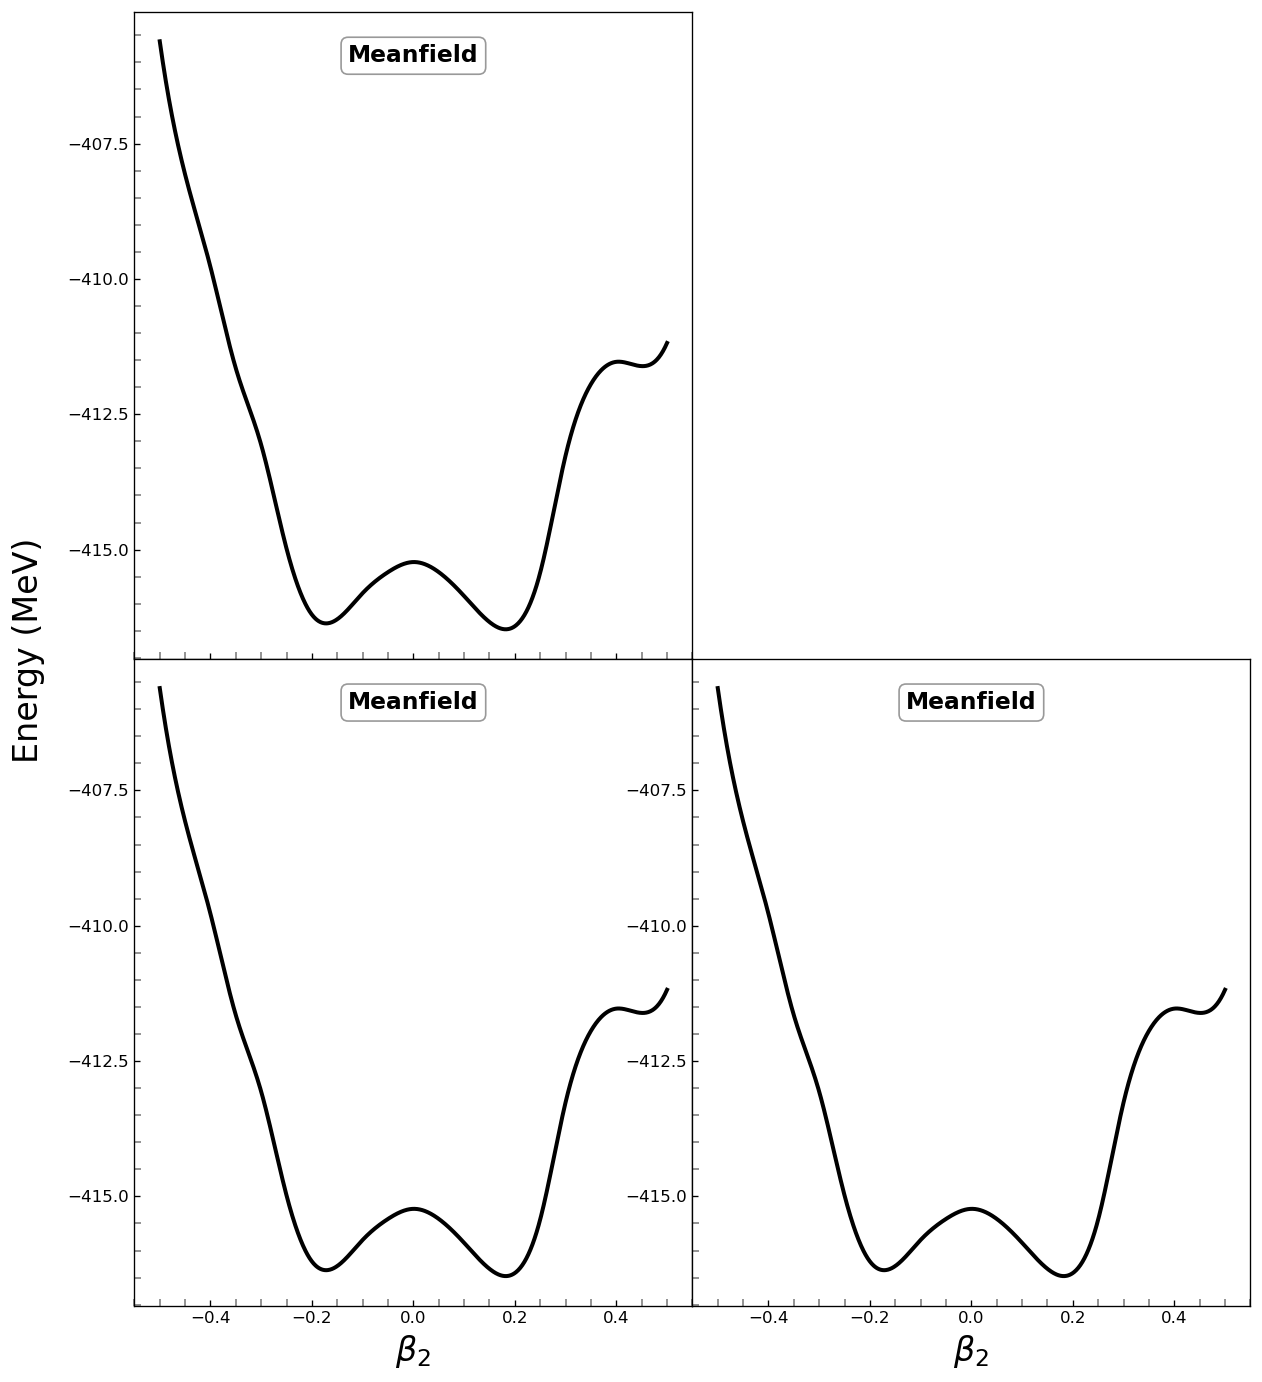

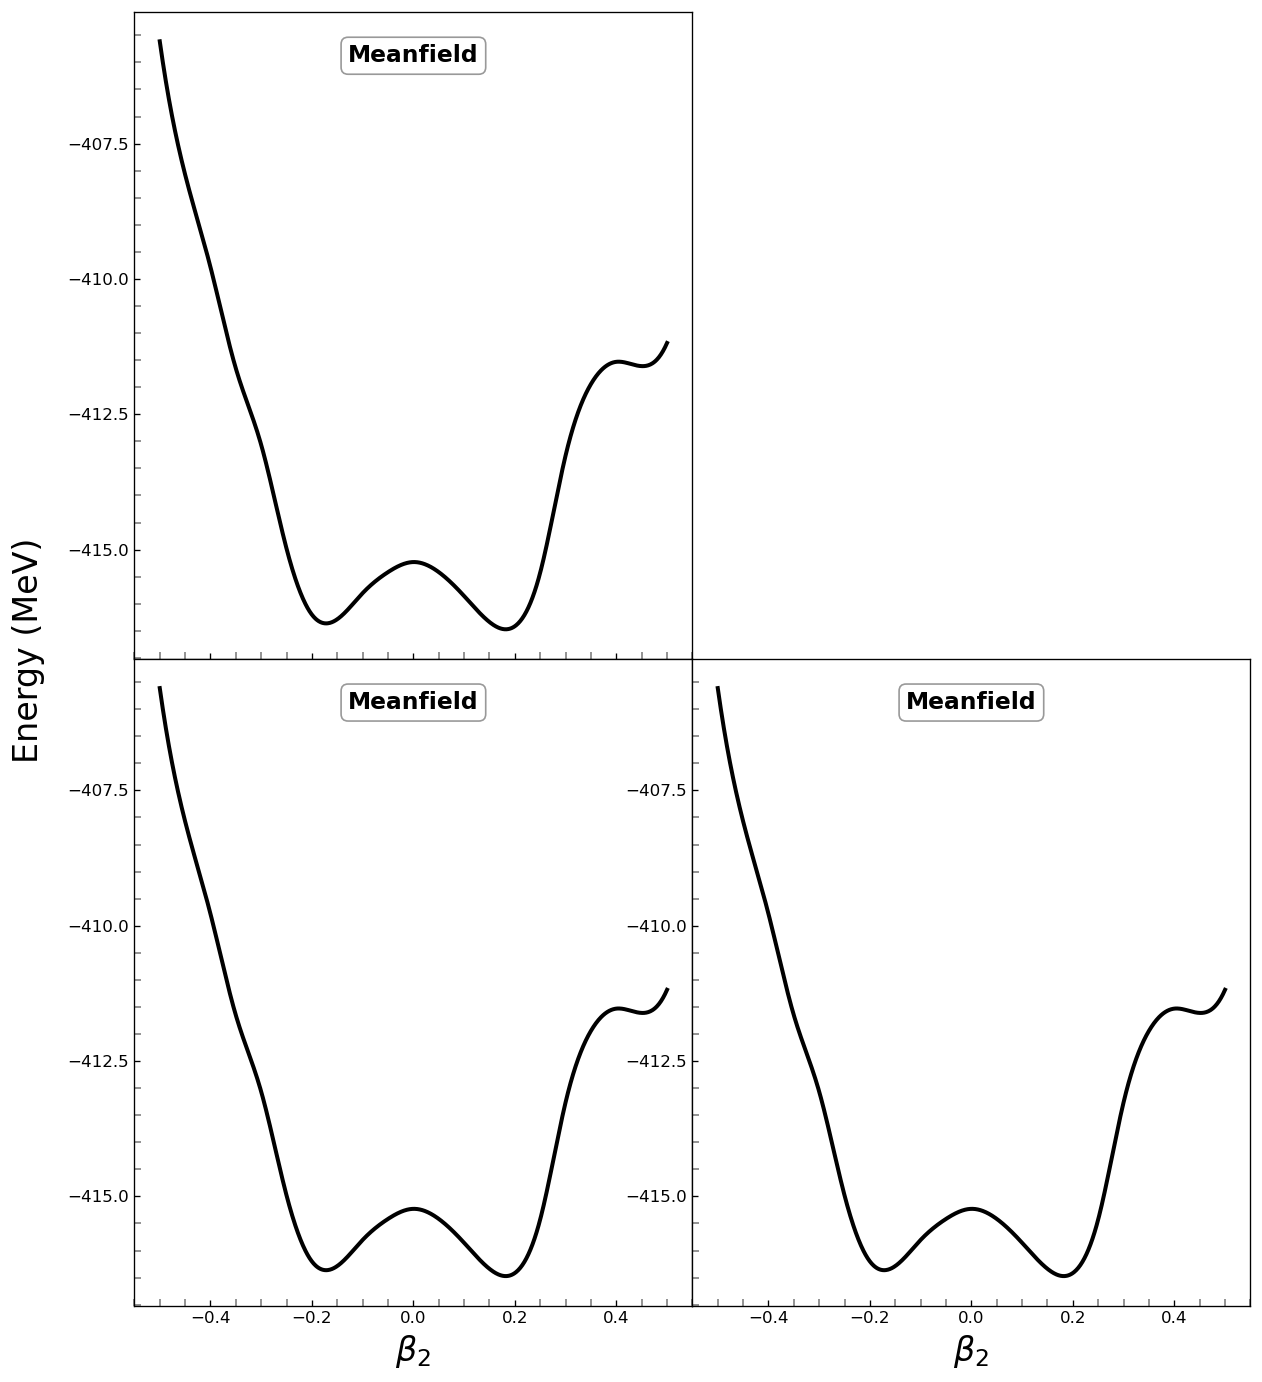

In [9]:
plot = Plot(
    
    subplot_configs=[config_A, config_A, config_A, ],  # 注意：config_A用了两次
    num_rows=2,                     # 2行
    num_cols=2,                     # 2列
    sub_ax_locations_list=[         # 每个子图的位置
        (0, 0),  # 第1个config_A → 左上
        (1, 0),  # 第2个config_A → 右上
        # (2, 0),  # config_B → 左下
        # (0, 1),
        (1, 1),  # config_C → 右下
        # (2, 1)
    ],
    xlabel=r"$\beta_2$",            # X轴标签（支持LaTeX）
    ylabel="Energy (MeV)",          # Y轴总标签
    figsize=(12, 14),               # 图像尺寸（英寸）
    position=(0, 1),         # 图例放在左上角子图
    closed_subplots=[(0, 1)]
)
plot.plot()

In [ ]:
import re
import os
import pandas as pd
import numpy as np
import shutil
# 读取 kernel文件，并将 kernel 文件组成一个dataframe
dirpath = f"/home/xizhang/MRCDFT-master/Labs/40Ca/40Ca_10_2026-07-14-09-44-24"
# Proj_40Ca_kern.1D_eMax04.05.12-010+001_+000+001.elem
# 正则匹配
k_pattern = (
    r'^(?P<prefix>Proj_)'
    r'(?P<m>\d{2})'
    r'(?P<name>[A-Z][a-z]?)'
    r'(?P<filename>_kern)\.'
    r'(?P<dim>\dD)'
    r'(?P<s>_eMax)'
    r'(?P<n0f>\d{2})\.'
    r'(?P<nphi>\d{2})\.'
    r'(?P<nbeta>\d{2})'
    r'(?P<beta2_l>[+-]\d{3})'
    r'(?P<beta3_l>[+-]\d{3})_'
    r'(?P<beta2_r>[+-]\d{3})'
    r'(?P<beta3_r>[+-]\d{3})\.elem'
)

r_pattern = (
    r'^(?P<prefix>Proj_)'
    r'(?P<m>\d{2})'
    r'(?P<name>[A-Z][a-z]?)'
    r'(?P<filename>_R2_2b)\.'
    r'(?P<dim>\dD)'
    r'(?P<s>_eMax)'
    r'(?P<n0f>\d{2})\.'
    r'(?P<nphi>\d{2})\.'
    r'(?P<nbeta>\d{2})'
    r'(?P<beta2_l>[+-]\d{3})'
    r'(?P<beta3_l>[+-]\d{3})_'
    r'(?P<beta2_r>[+-]\d{3})'
    r'(?P<beta3_r>[+-]\d{3})\.elem'
)
k_format = {
    1: {'method': 'space', 'key_point': ['J','K1','K2','Parity', 'N^2/N_KK','Z^2/N_KK', 'J^2/N_KK']}, 
    2: {'method': 'width', 'key_point': [("N_KKr",15), ('N_KKi',15), ('H_KKr',15), ('H_KKi',15)]},
    3: {'method': 'width', 'key_point': [("Nr",15), ('Ni',15), ('Zr',15), ('Zi',15)]},
    4: {'method': 'width', 'key_point': [("Q2_KK_12pr",15), ('Q2_KK_12pi',15), ('Q_KK_21pr',15), ('Q_KK_21pi',15)]},
    5: {'method': 'width', 'key_point': [("E0_KKpr",15), ('E0_KKpi',15), ('E0_KKpr',15), ('E0_KKpi',15)]},
    6: {'method': 'width', 'key_point': [("Q2_KK_12nr",15), ('Q2_KK_12ni',15), ('Q_KK_21nr',15), ('Q_KK_21ni',15)]},
    7: {'method': 'width', 'key_point': [("E0_KKnr",15), ('E0_KKni',15), ('E0_KKnr',15), ('E0_KKni',15)]},
}
r_format = {
    1: {'method': 'width', 'key_point': [("total_r2_1B",15), ('total_r2_2B',15), ('r2_1&2B',15)]}, 
    2: {'method': 'width', 'key_point': [("total_direct",15), ('total_exchange',15), ('total_kappa',15)]},
    3: {'method': 'width', 'key_point': [("o2",15), ('o5',15), ('1&2bn',15)]},
    4: {'method': 'width', 'key_point': [("2bndirect",15), ('2bnexchange',15), ('2bnkappa',15)]},
    5: {'method': 'width', 'key_point': [("o1",15), ('o3',15), ('1&2bp',15)]},
    6: {'method': 'width', 'key_point': [("2bpdirect",15), ('2bpexchange',15), ('2bpkappa',15)]},
    7: {'method': 'width', 'key_point': [("1bpn",15), ('o4',15), ('2bpn',15)]},
    8: {'method': 'width', 'key_point': [("2bpndirect",15), ('exchange',15), ('kappa',15)]},
}
class ParseMethod():
    
    def __init__(self):
        self.ctof = self.convert_values_from_char_to_float
    
    @staticmethod
    def convert_values_from_char_to_float(char):
        # 
        try:
            float_ = float(char)
        except ValueError:
            float_ = char  # 保留字符串（如 Parity 的 '+'）
            if char != "+":
                print(char)
        return float_
    

def parse_line(line, fmt_info):
    pm = ParseMethod()
    temp_dir = {}
    if fmt_info["method"] == 'space':
        fields = line.split()
        for i, field in enumerate(fields):
            temp_dir[fmt_info['key_point'][i]] = pm.ctof(field)
    elif fmt_info['method'] == 'width':
        # fields = line
        pos = 0
        for i, point in enumerate(fmt_info['key_point']):
            # print(point)
            field = line[pos: pos+point[1]]
            temp_dir[fmt_info['key_point'][i][0]] = pm.ctof(field)
            pos += point[1]
    return temp_dir
filename = 'Proj_40Ca_kern.1D_eMax04.05.12-010+001_+000+001.elem'
# print(os.getcwd())
def kernel_process(path, kernel_file, fmt_info, lines=7):
    # os.chdir(path)
    data_list = []
    
    dat = {}
    # print(match)
    
    # print(match)
    with open(os.path.join(path, kernel_file), 'r') as f:
        contents = f.readlines()
    # print(contents)
    for i, line in enumerate(contents):
        if line.split() != "":
            # print(1,line)
            dat.update(parse_line(line, fmt_info[i%lines+1]))
    # data_list.append(dat)
    if dat == {}:
        print(kernel_file)
    return dat
import re

def swap_beta2_fields(file, pattern):
    """
    匹配文件名并交换 beta2_l 和 beta2_r 的值。
    
    参数:
        file (str): 原始文件名
        pattern (str): 编译好的正则表达式字符串或 re.Pattern 对象
    
    返回:
        tuple: (fields_dict, new_filename)
            fields_dict: 匹配的所有命名组字典（字符串值）
            new_filename: 交换 beta2_l 和 beta2_r 后的新文件名
    """
    match = re.match(pattern, file)
    if not match:
        raise ValueError(f"File '{file}' does not match the given pattern.")
    
    fields = match.groupdict()  # 获取所有命名组
    
    # 提取 beta2_l 和 beta2_r 的值
    beta2_l_orig = fields['beta2_l']
    beta2_r_orig = fields['beta2_r']
    
    # 构造新文件名：在原文件名中交换这两个值
    # 注意：正则中 beta2_l 在 beta3_l 前面，beta2_r 在 beta3_r 前面，
    # 且 beta3_l 和 beta2_r 之间有一个下划线。
    # 为了避免替换冲突，使用临时占位符
    new_file = file.replace(beta2_l_orig, '___TEMP___', 1)  # 只替换第一次出现
    new_file = new_file.replace(beta2_r_orig, beta2_l_orig, 1)
    new_file = new_file.replace('___TEMP___', beta2_r_orig, 1)
    
    return fields, new_file

def fun(dirpath, pattern, format, lines): 
    templist = [] 
    # existing_files = set(os.listdir(dirpath))
    for file in os.listdir(dirpath):
        # print(file)
        match = re.match(pattern, file)
        # print(match.group())
        if match:
            # print(match.groupdict())
            _, new_file = swap_beta2_fields(file, pattern)
            # if match.group("prefix") + match.group():
                # print()
            if new_file not in os.listdir(dirpath):
                src_path = os.path.join(dirpath, file)
                dst_path = os.path.join(dirpath, new_file)
                shutil.copy2(src_path, dst_path)   # 复制并保留元数据
                # existing_files.add(new_file)       # 更新已存在文件集合
            name_list = ['n0f', 'beta2_l', 'beta3_l','beta2_r','beta3_r', 'nbeta']
            templist.append({**kernel_process(dirpath, file, format, lines),**{
                
                    it: (float(match.group(it)) * 0.01 if "beta" in it else float(match.group(it)))
                    for it in name_list
                }} )    
            # print(templist) 
    return templist  



In [7]:
fdir = "/home/xizhang/MRCDFT-master/Labs/40Ca"
# a = "40Ca_10_2026-07-14-09-44-24/output"
# a = 'rtwobodycal/40Ca_10_2026-07-14-12-02-52/output'
# a = 'rtwobodycal/40Ca_12_2026-07-14-12-16-46/output'
a = 'rtwobodycal/40Ca_14_2026-07-14-12-22-18/output'
b = "/home/xizhang/MRCDFT-master/Labs/40Ca/40Ca_10_2026-07-14-09-44-24"
dirpath = os.path.join(fdir,a)
# print(templist)
dfk = pd.DataFrame(fun(dirpath, k_pattern, k_format, 7))
dfr = pd.DataFrame(fun(dirpath, r_pattern, r_format, 8))
# pd.DataFrame(fun(dirpath, r_pattern, r_format, 7))
# print(contents)
# print(dfr)
merge_keys = ['n0f', 'beta2_l', 'beta3_l', 'beta2_r', 'beta3_r', 'nbeta']
merge_df = pd.merge(dfk, dfr, on=merge_keys, how='outer')
# print(merge_df)
merge_df['E0'] = merge_df['E0_KKpr']/merge_df['N_KKr']
# print(merge_df.columns)
df_last = merge_df[['n0f','beta2_l','beta2_r','E0','o1', 'o2', 'o3','o4','o5' 
                    # 'direct', 'exchange', 'kappa'
                    ]].copy()


# df_last['error'] = df_last['E0']-df_last['r2_1B']
# df_last['r^2e'] = np.sqrt(df_last['E0']/20)
# df_last['r^21'] = np.sqrt(df_last['r2_1B']/20)
# df_last['err'] = df_last['r^2e']-df_last['r^21']
# df_last['r^2'] = np.sqrt(df_last['E0']/20 + df_last['r2_2B']/400)
df_last['sqrtr1bE'] = np.sqrt(df_last['E0']/20)
df_last['sqrto1'] =  np.sqrt(df_last['o1']/20)
df_last['error'] = (df_last['sqrtr1bE']-df_last['sqrto1'])

print(df_last)
df_last.to_csv("nf14.csv")

    n0f  beta2_l  beta2_r          E0         o1         o2         o3  \
0  14.0     -0.5     -0.5  260.997939  260.99072  253.91859 -137.28845   
1  14.0     -0.5      0.1  240.988351  240.98654  233.32064 -114.34382   
2  14.0     -0.5      0.2  249.235564  249.23435  242.17696 -126.58577   
3  14.0      0.1     -0.5  240.988351  240.98654  233.32064 -114.34382   
4  14.0      0.1      0.1  231.612038  231.60531  225.64520 -111.80854   
5  14.0      0.1      0.2  231.286071  231.27974  225.45022 -110.67773   
6  14.0      0.2     -0.5  249.235564  249.23435  242.17696 -126.58577   
7  14.0      0.2      0.1  231.286071  231.27974  225.45022 -110.67773   
8  14.0      0.2      0.2  231.734586  231.72848  225.64489 -110.01434   

         o4         o5  sqrtr1bE    sqrto1     error  
0  0.000064 -135.40067  3.612464  3.612414  0.000050  
1  0.000594 -112.66713  3.471227  3.471214  0.000013  
2  0.001084 -124.94217  3.530124  3.530116  0.000009  
3  0.000594 -112.66713  3.471227  3.471

In [5]:
fdir = "/home/xizhang/MRCDFT-master/Labs/40Ca/conver"
import os 
df_list = []
for _dir in os.listdir(fdir):
    
    filepath = os.path.join(fdir, _dir, "output")
    print(_dir)
    # print(templist)
    dfk = pd.DataFrame(fun(filepath, k_pattern, k_format, 7))
    dfr = pd.DataFrame(fun(filepath, r_pattern, r_format, 2))
    # pd.DataFrame(fun(dirpath, r_pattern, r_format, 7))
    # print(contents)
    # print(dfr)
    
    merge_keys = ['n0f', 'beta2_l', 'beta3_l', 'beta2_r', 'beta3_r', 'nbeta']
    merge_df = pd.merge(dfk, dfr, on=merge_keys, how='outer')
    # print(merge_df)
    merge_df['E0'] = merge_df['E0_KKpr']/merge_df['N_KKr']
    # print(merge_df.columns)
    df_last = merge_df[['n0f','beta2_l','beta2_r','nbeta','E0','r2_1B', 'r2_2B', 'r2_1&2B', 
                        # 'direct', 'exchange', 'kappa'
                        ]].copy()


    df_last['error'] = df_last['E0']-df_last['r2_1B']
    df_last['r^2e'] = np.sqrt(df_last['E0']/20)
    df_last['r^21'] = np.sqrt(df_last['r2_1B']/20)
    df_last['err'] = df_last['r^2e']-df_last['r^21']
    df_last['r^2'] = np.sqrt(df_last['E0']/20 + df_last['r2_2B']/400)
    df_list.append(df_last)
# df_list.pop(1)
print(df_list[4].head())

40Ca_8_2026-07-05-13-24-37
40Ca_4_2026-07-05-13-20-19
40Ca_12_2026-07-06-08-48-50
40Ca_10_2026-07-06-08-48-40
40Ca_14_2026-07-06-10-05-00
40Ca_6_2026-07-05-14-23-41
    n0f  beta2_l  beta2_r  nbeta          E0      r2_1B      r2_2B    r2_1&2B  \
0  14.0     -0.5     -0.5   0.12  260.997939  260.99072 -137.28845  123.70227   
1  14.0     -0.5     -0.4   0.12  252.112702  252.10435 -132.37879  119.72556   
2  14.0     -0.5     -0.3   0.12  247.588498  247.58164 -128.38409  119.19755   
3  14.0     -0.5     -0.2   0.12  249.159061  249.15548 -128.01740  121.13808   
4  14.0     -0.5     -0.1   0.12  248.011109  248.01002 -125.19044  122.81958   

      error      r^2e      r^21       err       r^2  
0  0.007219  3.612464  3.612414  0.000050  3.564642  
1  0.008352  3.550442  3.550383  0.000059  3.503525  
2  0.006858  3.518441  3.518392  0.000049  3.472530  
3  0.003581  3.529583  3.529557  0.000025  3.483950  
4  0.001089  3.521442  3.521435  0.000008  3.476720  


In [6]:
df_all = pd.concat(df_list, ignore_index=True)
# 确保 n0f 是数值型
df_all['n0f'] = df_all['n0f'].astype(float)
import numpy as np
import pandas as pd

# 假设 df_all 包含列：n0f, error
metrics = df_all.groupby('n0f')['error'].agg(
    mean_error='mean',
    rmse_error=lambda x: np.sqrt(np.mean(x**2)),
    max_error='max',
    median_error='median'
).reset_index()

print(metrics)
# print(df_all)

    n0f  mean_error  rmse_error  max_error  median_error
0   4.0    2.241984    2.687764  11.235469      1.839686
1   6.0    0.118542    0.124154   0.228665      0.117510
2   8.0    0.138477    0.141659   0.193963      0.154714
3  10.0    0.069545    0.071261   0.097829      0.073262
4  12.0    0.010573    0.011436   0.033694      0.010091
5  14.0    0.005500    0.006058   0.012515      0.005718


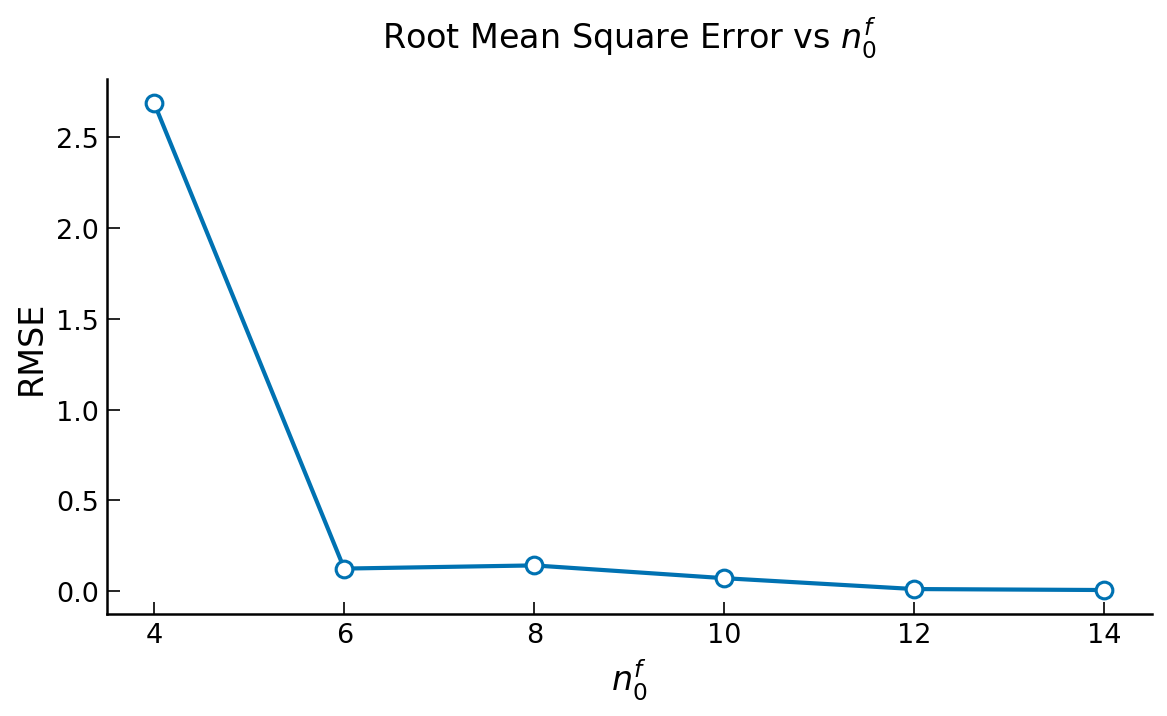

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1. 计算每个 n0f 的 RMSE ----------
# 假设 df_all 包含列：n0f, error
rmse_per_n0f = df_all.groupby('n0f')['error'].agg(
    lambda x: np.sqrt(np.mean(x**2))
).reset_index()
rmse_per_n0f.columns = ['n0f', 'RMSE']

# 按 n0f 排序
rmse_per_n0f = rmse_per_n0f.sort_values('n0f')

# ---------- 2. 全局字体与样式（顶刊配置） ----------
plt.rcParams.update({
    # 'font.family': 'serif',
    # 'font.serif': ['Times New Roman'],
    'font.size': 14,
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'axes.spines.top': False,    # 去掉上框线
    'axes.spines.right': False,  # 去掉右框线
})

# ---------- 3. 绘图 ----------
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

# 绘制折线图（带圆形标记）
ax.plot(rmse_per_n0f['n0f'], rmse_per_n0f['RMSE'],
        marker='o', markersize=8, linewidth=2,
        color='#0072B2',          # 顶刊常用蓝色
        markerfacecolor='white',  # 空心标记更学术
        markeredgewidth=1.5,
        markeredgecolor='#0072B2')

# 若想用柱状图，取消注释下面两行，注释掉上面 ax.plot 块
# ax.bar(rmse_per_n0f['n0f'], rmse_per_n0f['RMSE'],
#        width=0.6, color='#0072B2', edgecolor='black', linewidth=0.8)

# ---------- 4. 坐标轴标签与标题 ----------
ax.set_xlabel(r'$n_{0}^{f}$', fontsize=16)
ax.set_ylabel('RMSE', fontsize=16)
ax.set_title('Root Mean Square Error vs $n_{0}^{f}$', fontsize=16, pad=15)

# ---------- 5. 刻度设置 ----------
ax.tick_params(axis='both', which='major', labelsize=13)
ax.set_xticks(rmse_per_n0f['n0f'])  # 确保每个 n0f 值都有刻度

# ---------- 6. 网格线（可选，科研图一般不加，但若需要极淡的参考线可开启下面一行） ----------
# ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.3)

# ---------- 7. 保存与显示 ----------
plt.tight_layout()
plt.savefig('RMSE_vs_n0f.pdf', bbox_inches='tight')  # 矢量图
plt.show()

   n0f  beta2_l  beta2_r  nbeta          E0      r2_1B     r2_2B    r2_1&2B  \
0  8.0     -0.5     -0.5   0.12  258.435382  258.36376 -136.0443  122.31946   

      error      r^2e      r^21       err       r^2  
0  0.071622  3.594686  3.594188  0.000498  3.547063  


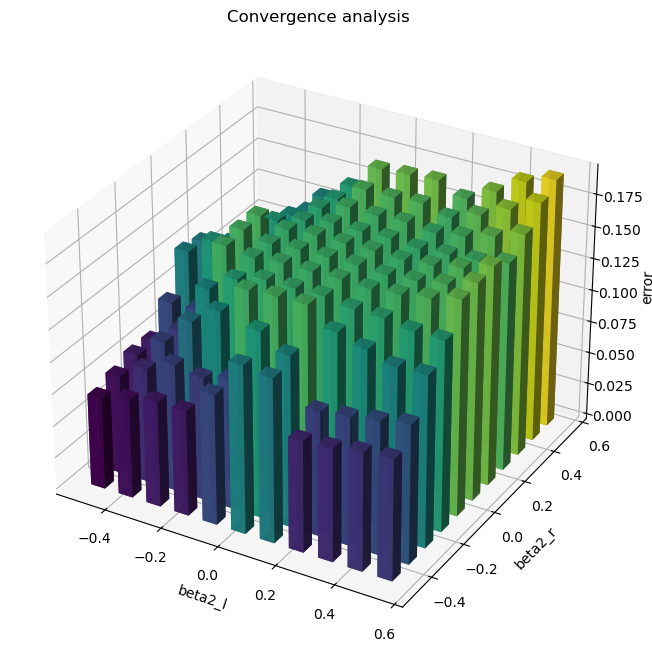

   n0f  beta2_l  beta2_r  nbeta          E0      r2_1B      r2_2B    r2_1&2B  \
0  4.0     -0.5     -0.5   0.12  256.926639  245.69117 -140.68779  105.00338   

       error      r^2e      r^21       err       r^2  
0  11.235469  3.584178  3.504933  0.079245  3.534772  


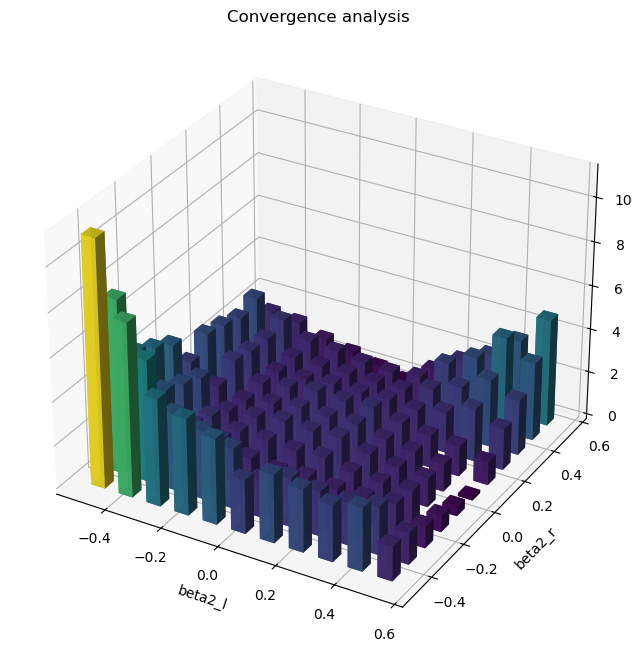

    n0f  beta2_l  beta2_r  nbeta          E0      r2_1B      r2_2B    r2_1&2B  \
0  12.0     -0.5     -0.5   0.12  260.767154  260.73346 -136.87277  123.86068   

      error      r^2e      r^21       err       r^2  
0  0.033694  3.610867  3.610633  0.000233  3.563169  


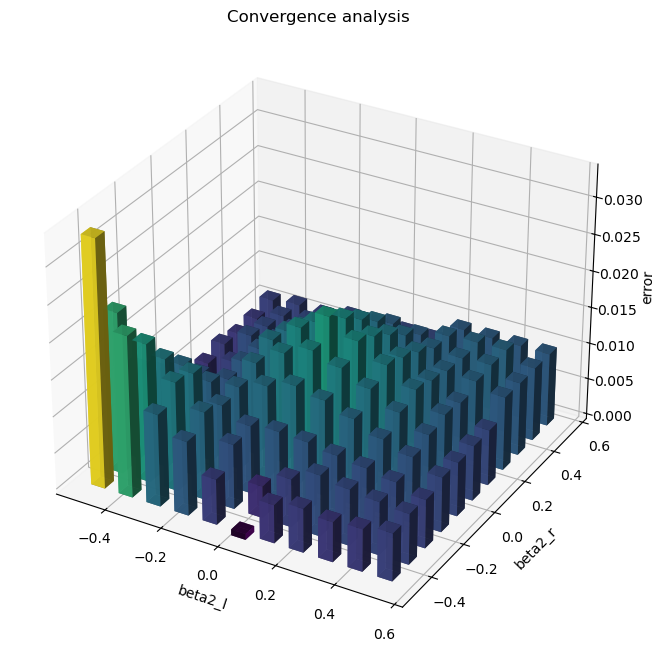

    n0f  beta2_l  beta2_r  nbeta          E0      r2_1B     r2_2B    r2_1&2B  \
0  10.0     -0.5     -0.5   0.12  259.894489  259.79666 -136.5443  123.25236   

      error     r^2e      r^21       err       r^2  
0  0.097829  3.60482  3.604141  0.000679  3.557157  


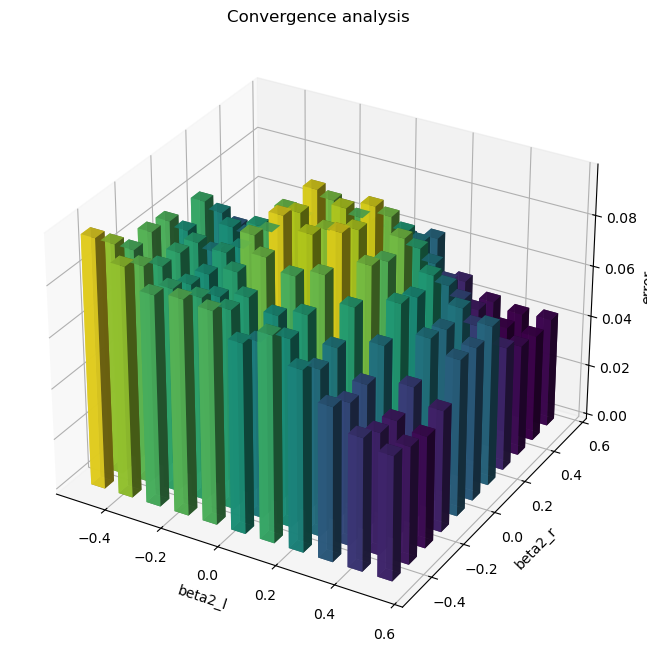

    n0f  beta2_l  beta2_r  nbeta          E0      r2_1B      r2_2B    r2_1&2B  \
0  14.0     -0.5     -0.5   0.12  260.997939  260.99072 -137.28845  123.70227   

      error      r^2e      r^21      err       r^2  
0  0.007219  3.612464  3.612414  0.00005  3.564642  


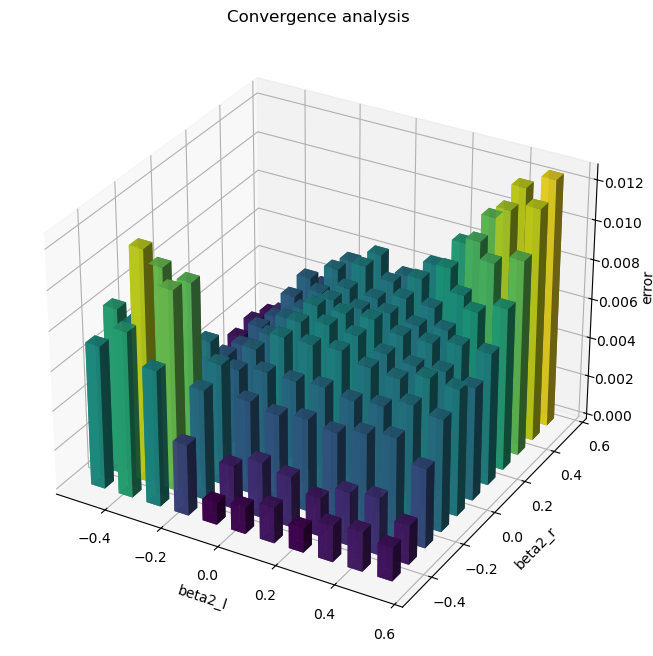

   n0f  beta2_l  beta2_r  nbeta          E0      r2_1B      r2_2B   r2_1&2B  \
0  6.0     -0.5     -0.5   0.12  256.451385  256.22272 -134.73202  121.4907   

      error      r^2e      r^21       err       r^2  
0  0.228665  3.580862  3.579265  0.001597  3.533517  


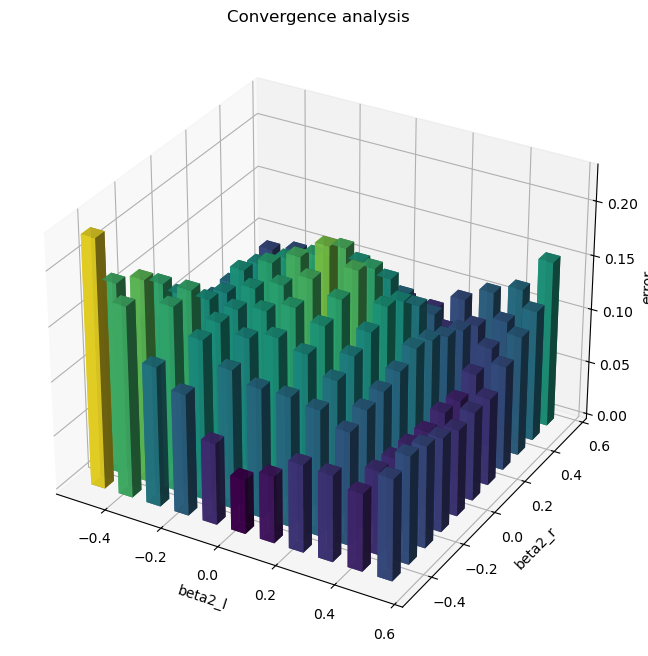

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#F0E442', '#56B4E9']
for i in range(0, len(df_list)):
    df_last = df_list[i]
    print(df_last.head(1))
    # 提取数据（假设 df_last 已存在）
    x = df_last['beta2_l'].values
    y = df_last['beta2_r'].values
    z = df_last['error'].values

    # 柱子参数（可根据数据范围调整）
    dx = dy = 0.05   # 柱子底边宽度（留空隙）
    dz = z          # 高度

    # 颜色映射
    norm = plt.Normalize(z.min(), z.max())
    colors = plt.cm.viridis(norm(z))
    

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.bar3d(x, y, np.zeros_like(z), dx, dy, dz,
            color=colors, shade=True, alpha=0.9)

    ax.set_xlabel('beta2_l')
    ax.set_ylabel('beta2_r')
    ax.set_zlabel('error')
    ax.set_title('Convergence analysis')
    plt.show()

   n0f  beta2_l  beta2_r  nbeta          E0      r2_1B      r2_2B    r2_1&2B  \
0  4.0     -0.5     -0.5   0.12  256.926639  245.69117 -140.68779  105.00338   

       error      r^2e      r^21       err       r^2  
0  11.235469  3.584178  3.504933  0.079245  3.534772  


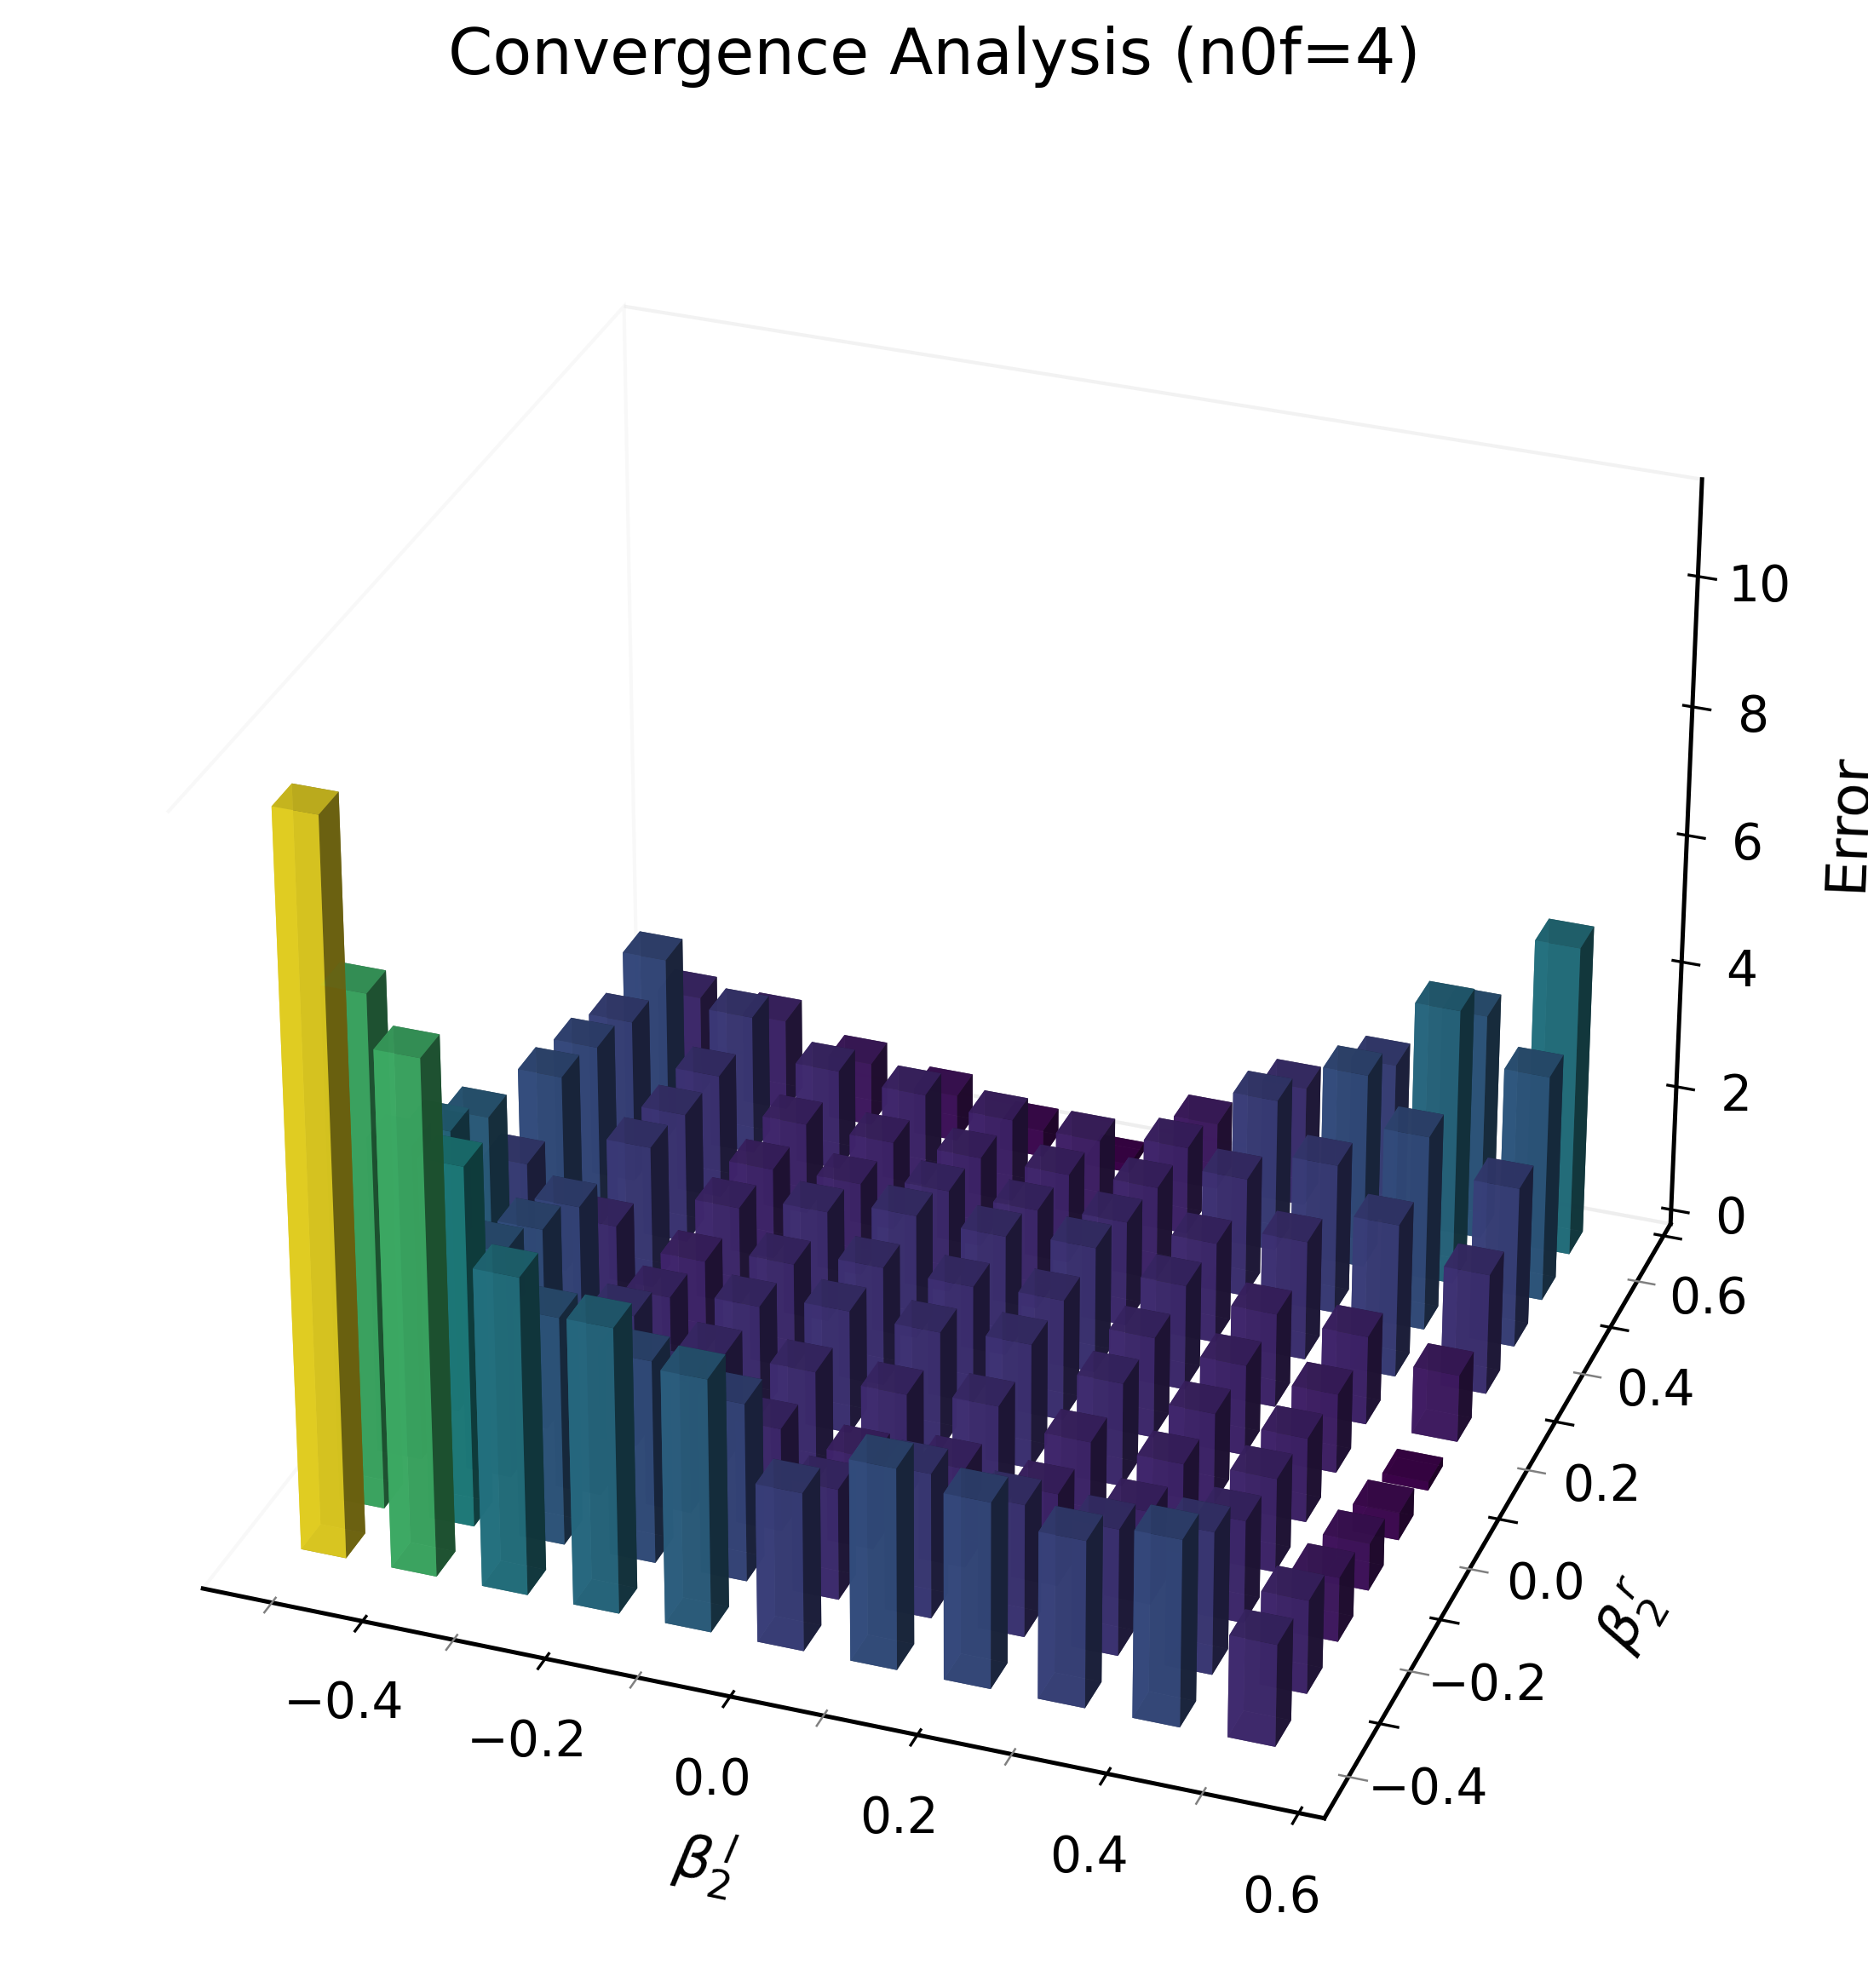

   n0f  beta2_l  beta2_r  nbeta          E0      r2_1B      r2_2B   r2_1&2B  \
0  6.0     -0.5     -0.5   0.12  256.451385  256.22272 -134.73202  121.4907   

      error      r^2e      r^21       err       r^2  
0  0.228665  3.580862  3.579265  0.001597  3.533517  


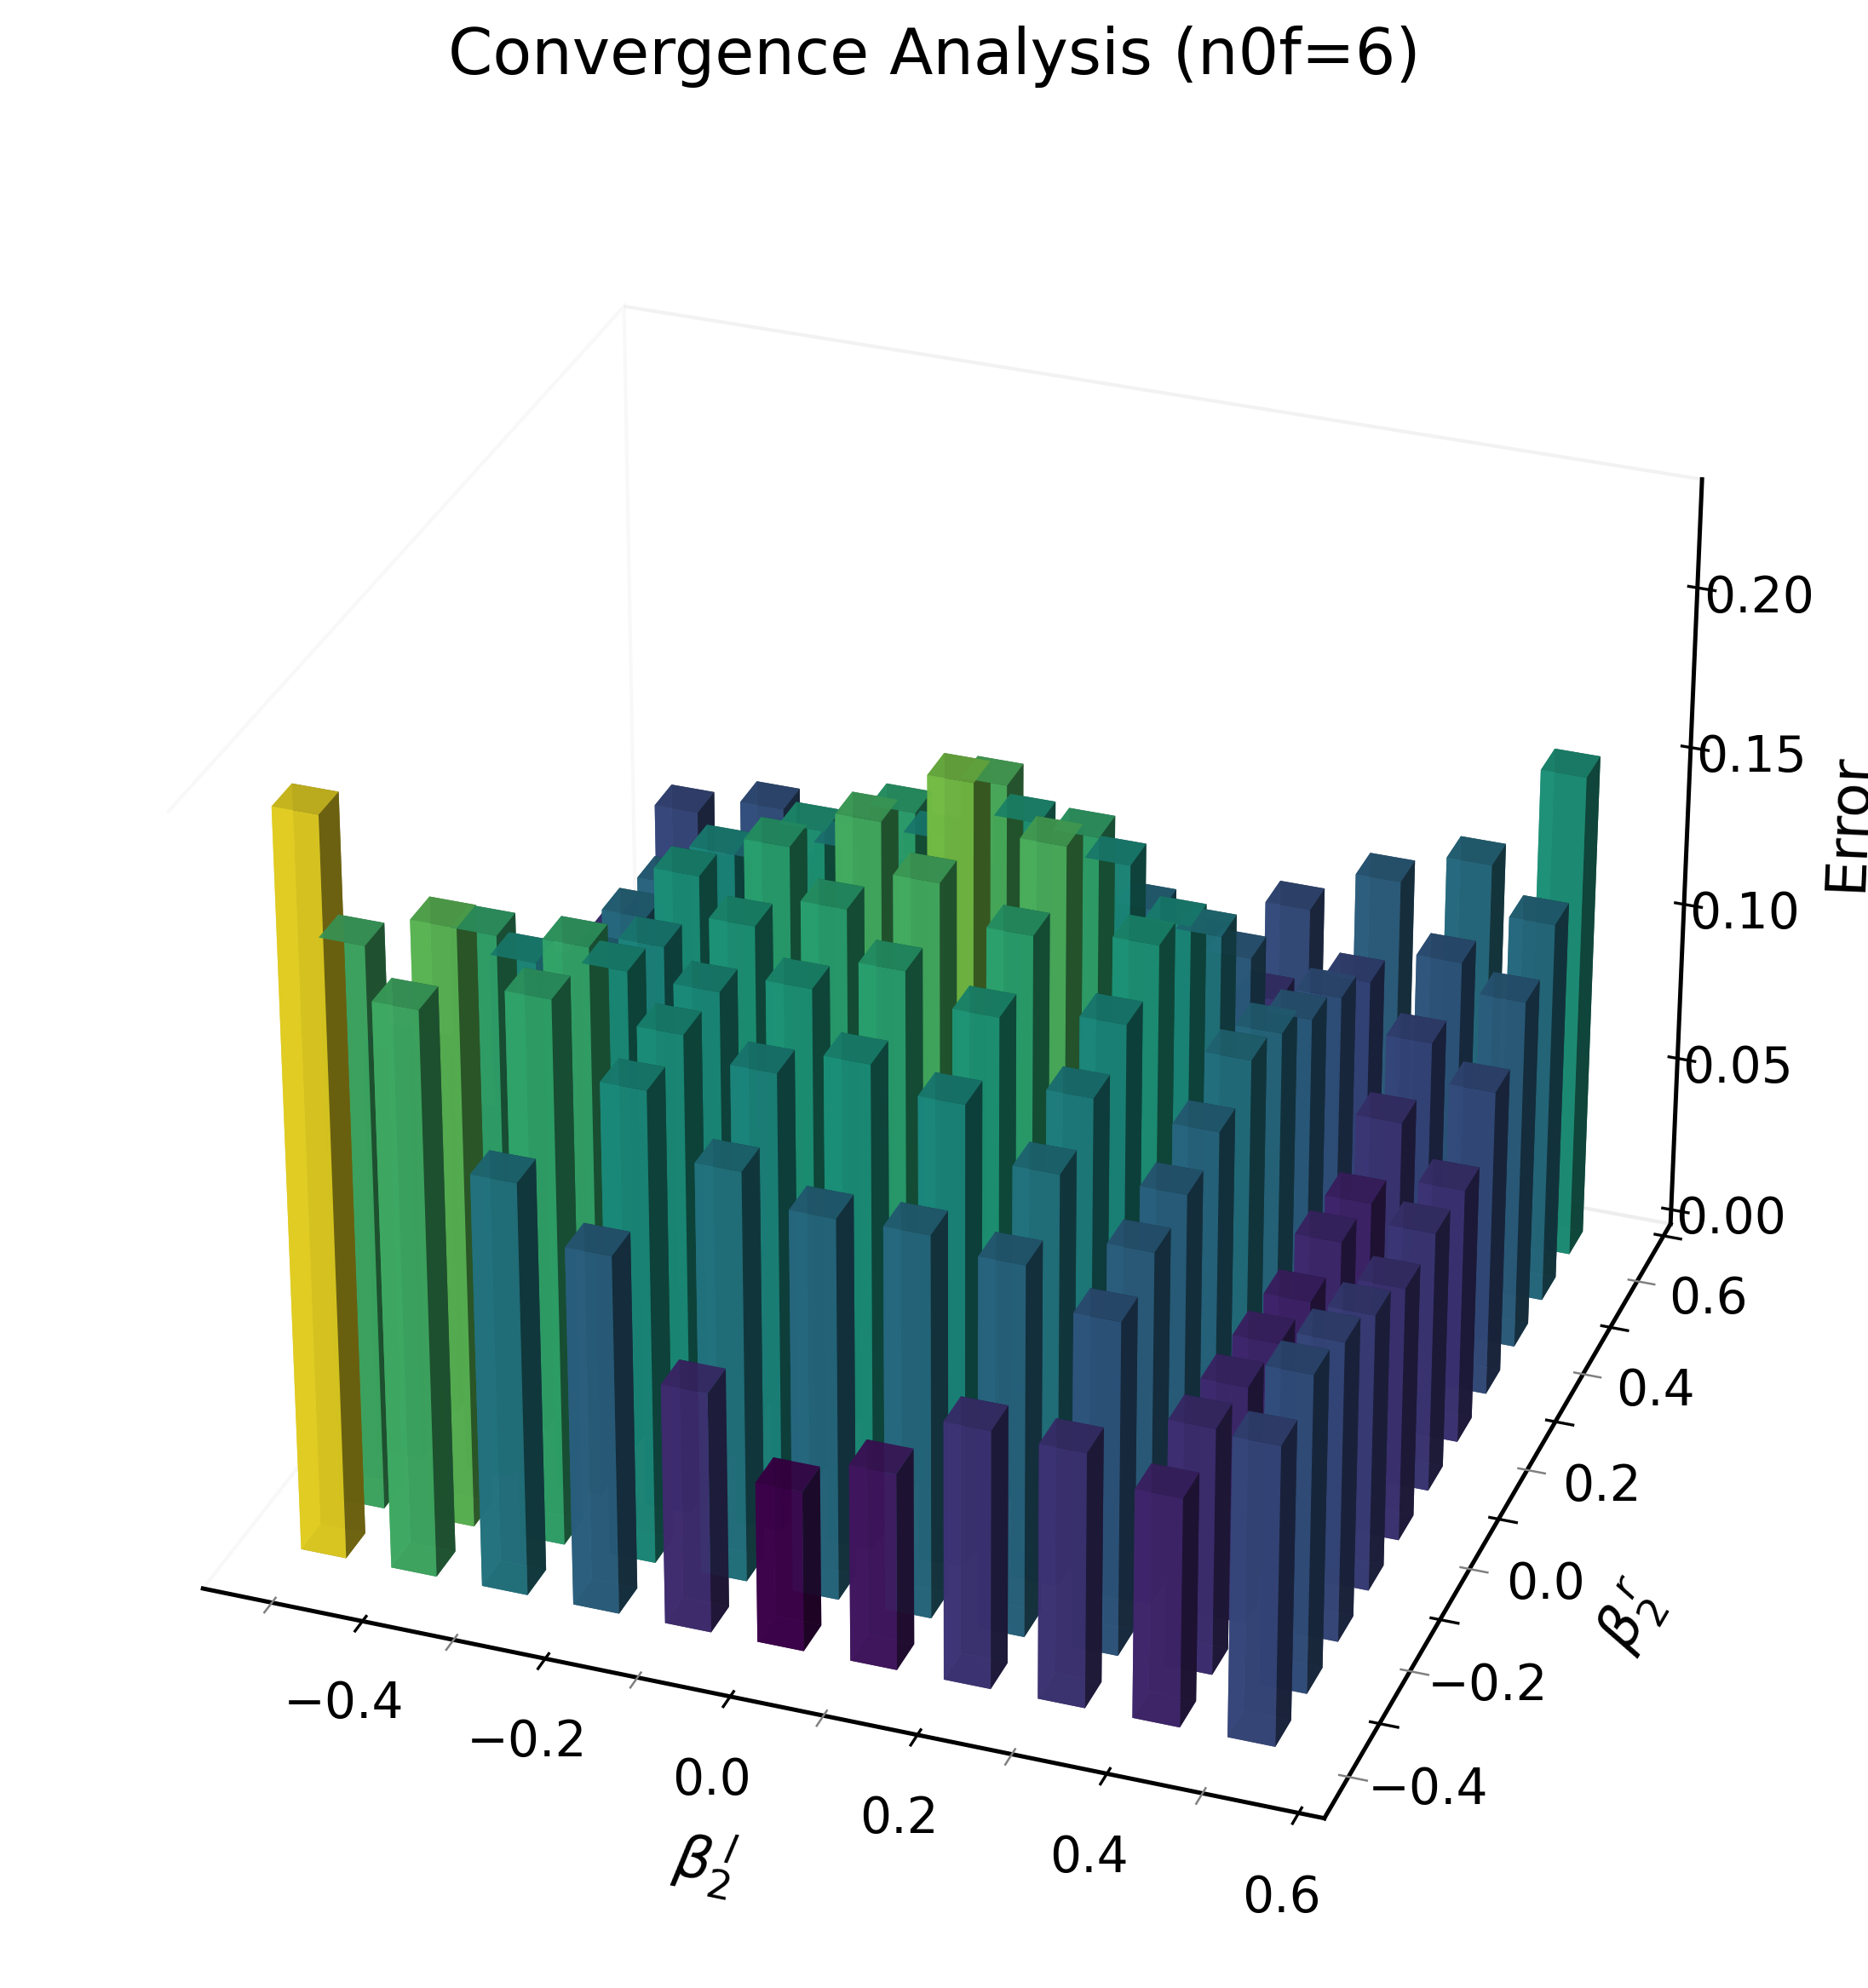

   n0f  beta2_l  beta2_r  nbeta          E0      r2_1B     r2_2B    r2_1&2B  \
0  8.0     -0.5     -0.5   0.12  258.435382  258.36376 -136.0443  122.31946   

      error      r^2e      r^21       err       r^2  
0  0.071622  3.594686  3.594188  0.000498  3.547063  


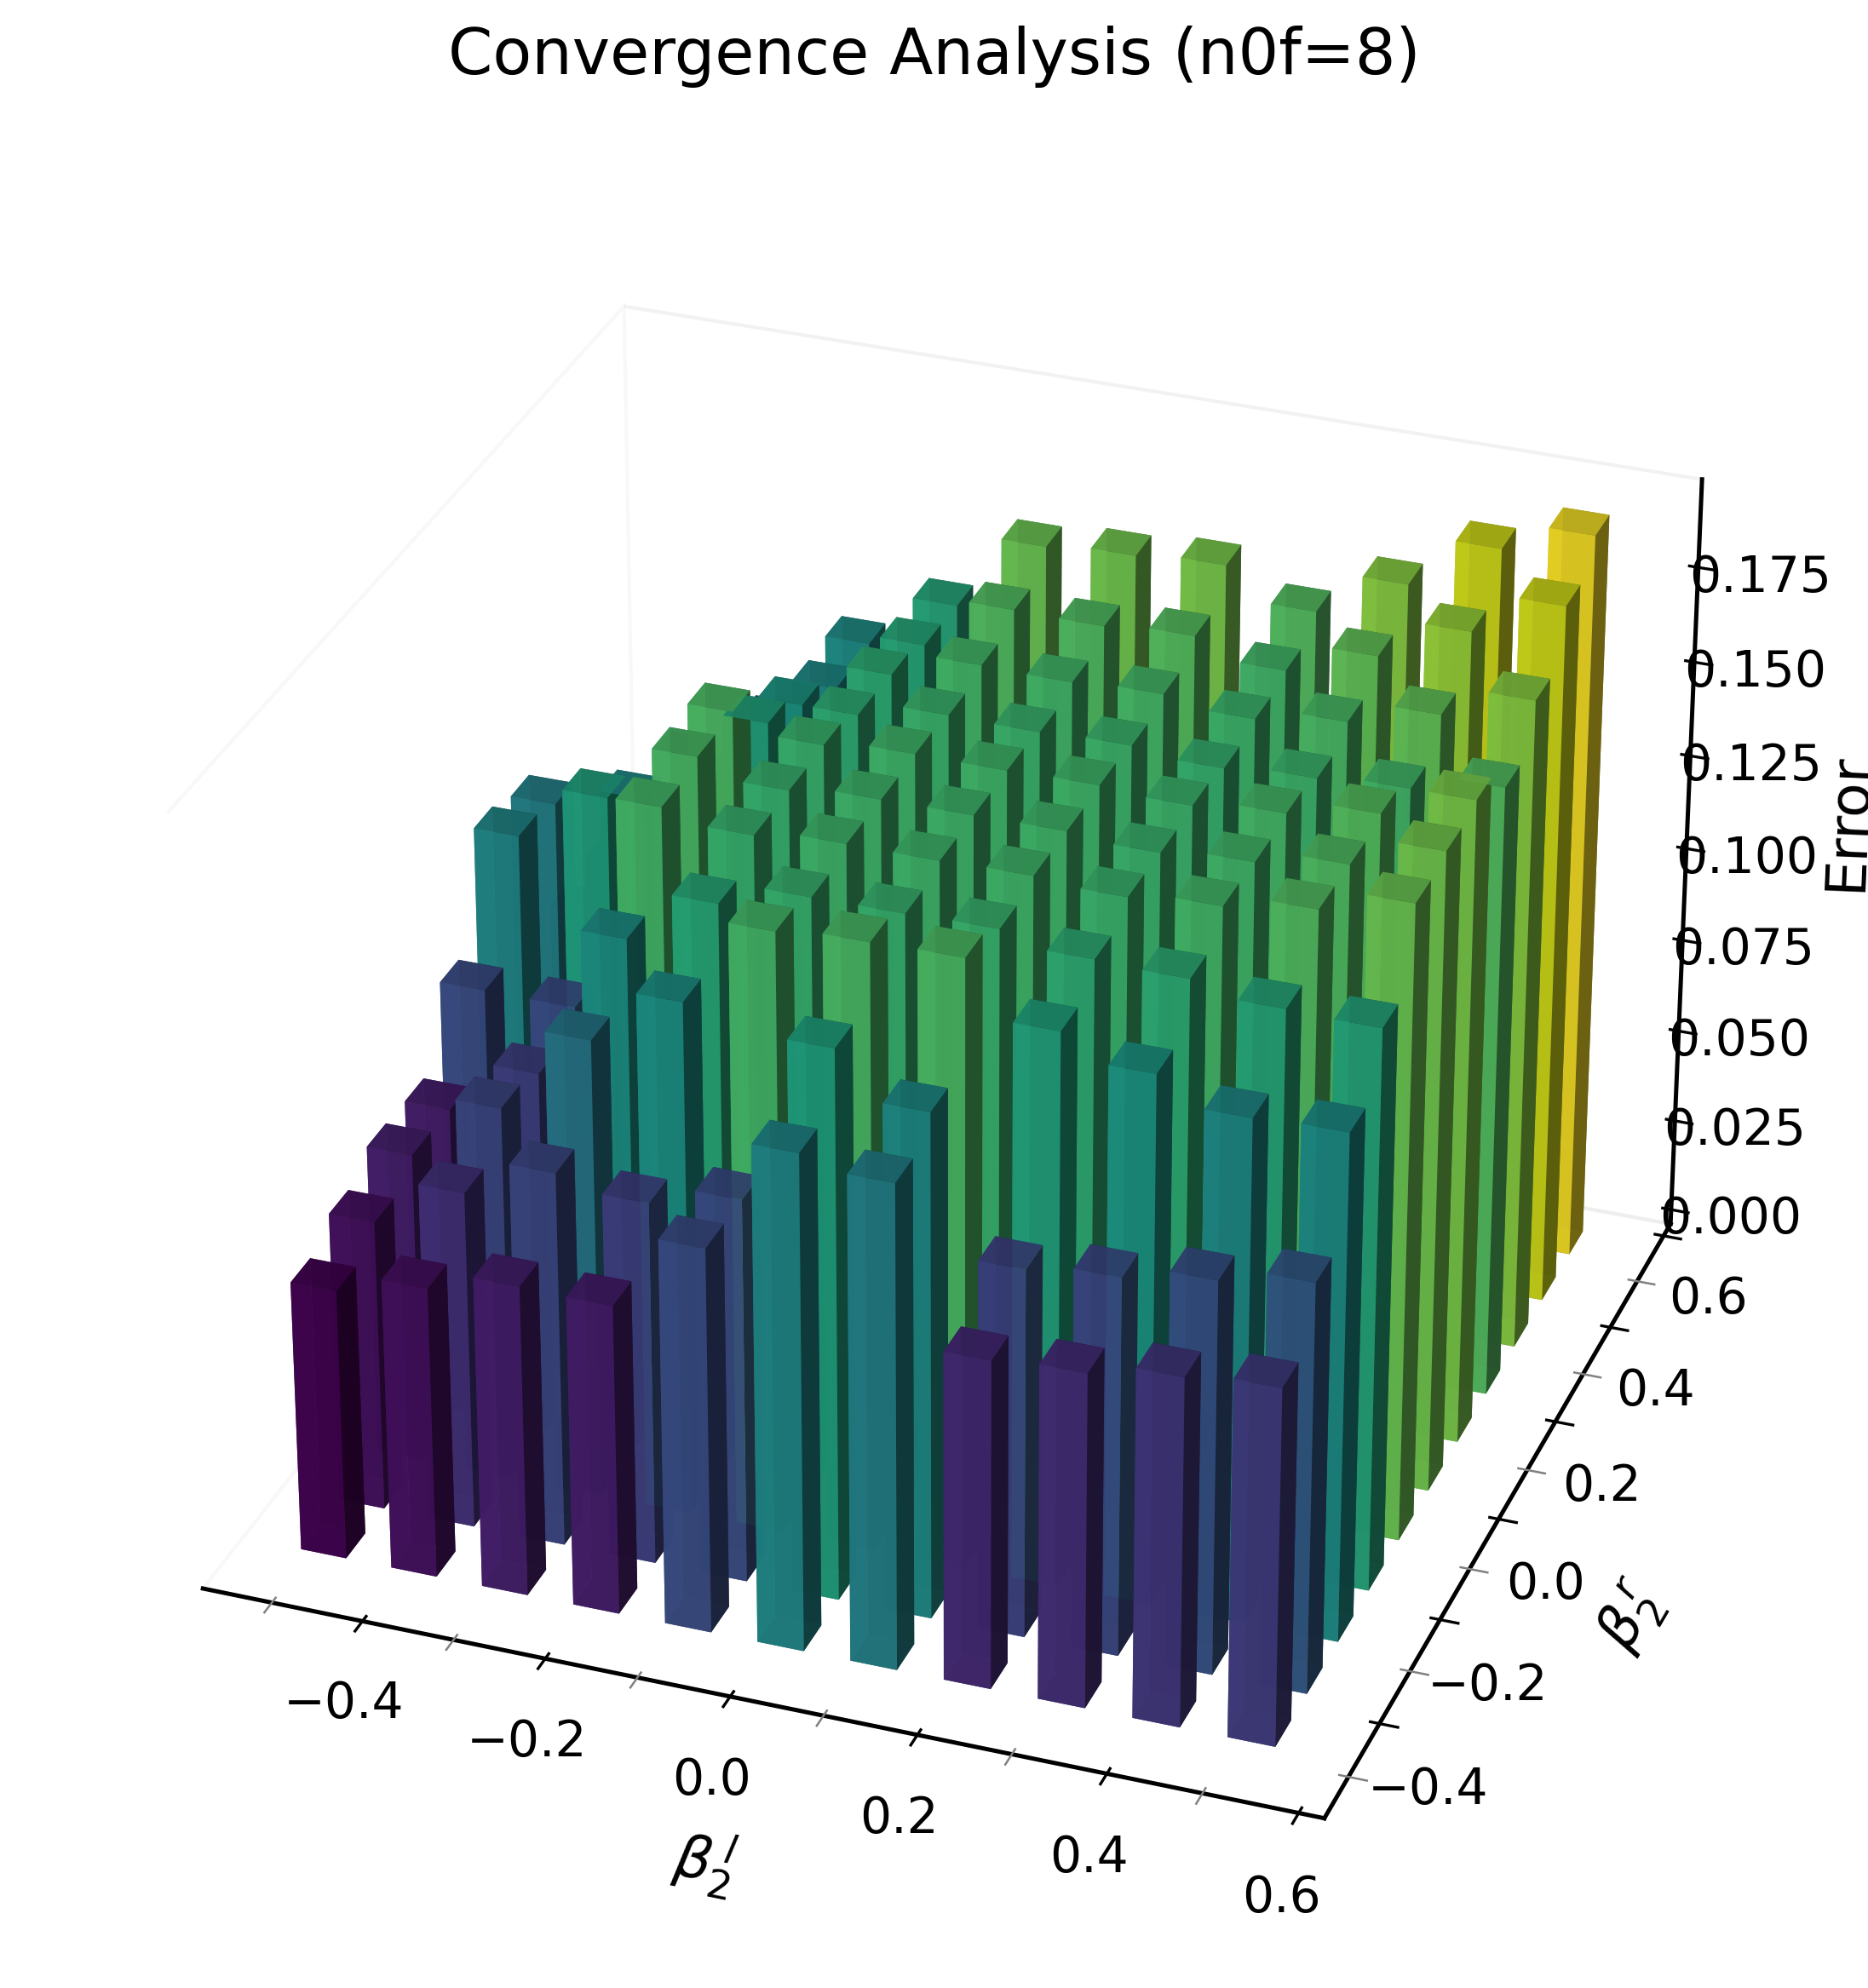

    n0f  beta2_l  beta2_r  nbeta          E0      r2_1B     r2_2B    r2_1&2B  \
0  10.0     -0.5     -0.5   0.12  259.894489  259.79666 -136.5443  123.25236   

      error     r^2e      r^21       err       r^2  
0  0.097829  3.60482  3.604141  0.000679  3.557157  


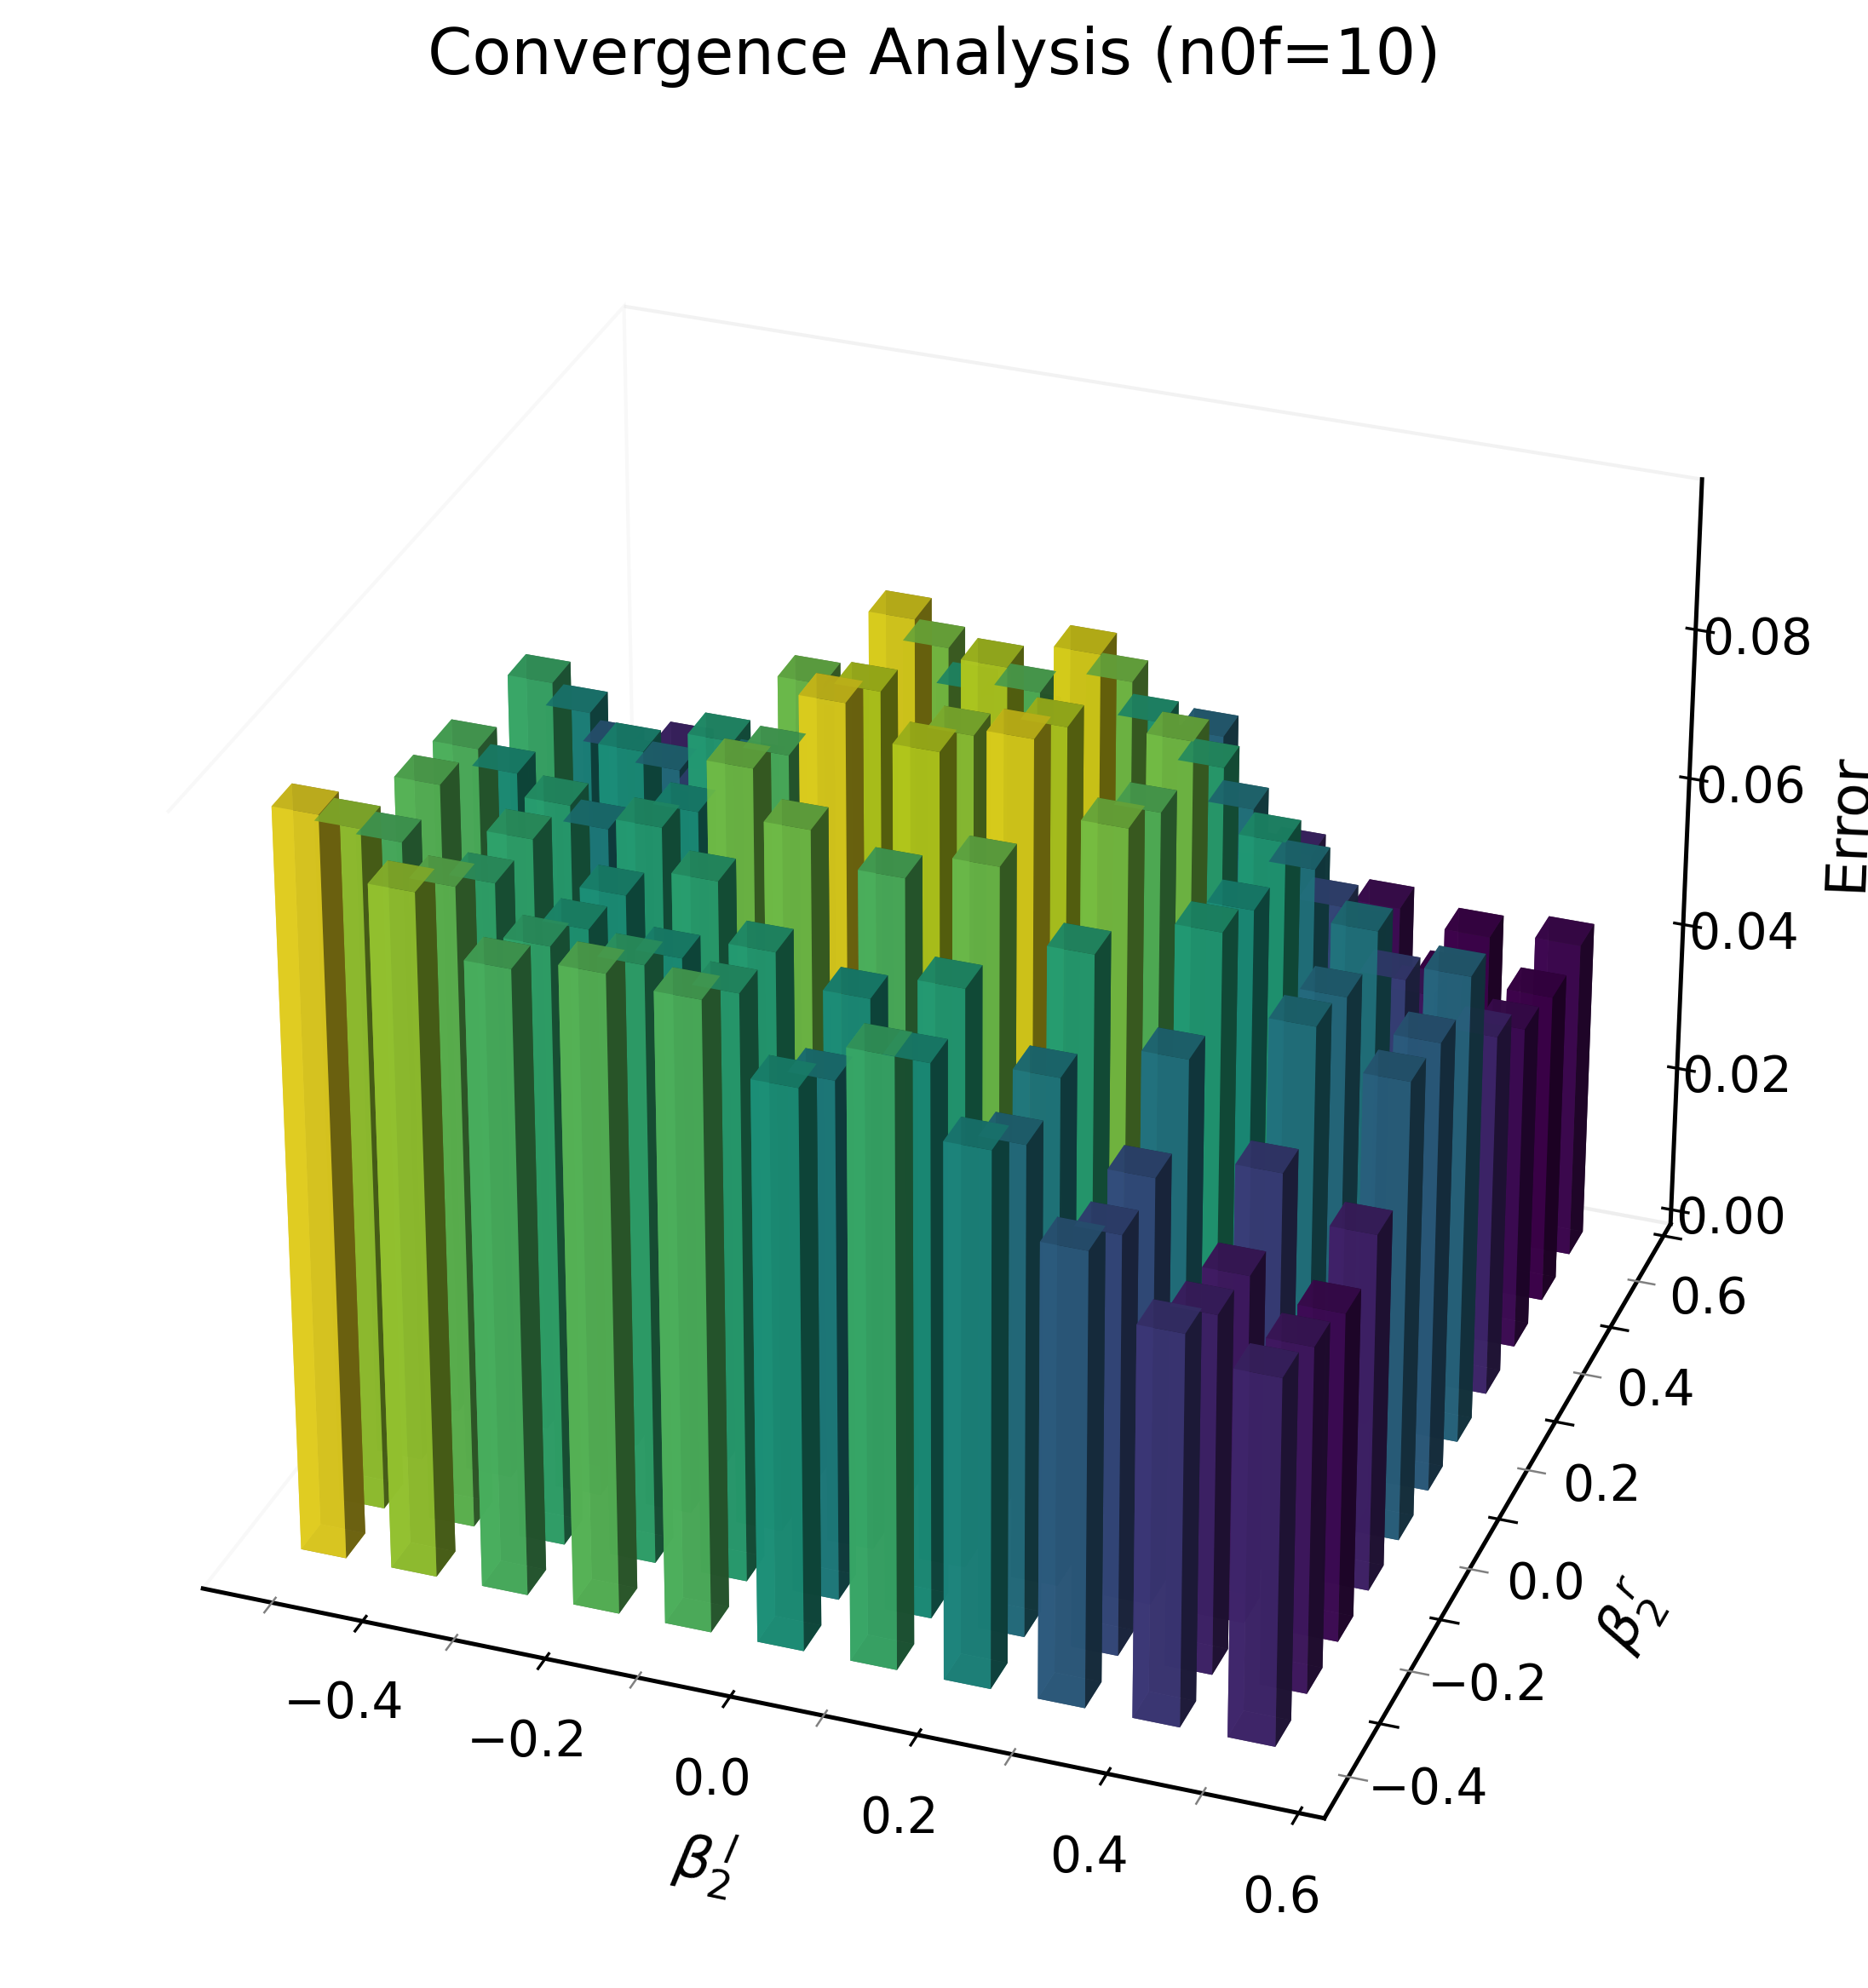

    n0f  beta2_l  beta2_r  nbeta          E0      r2_1B      r2_2B    r2_1&2B  \
0  12.0     -0.5     -0.5   0.12  260.767154  260.73346 -136.87277  123.86068   

      error      r^2e      r^21       err       r^2  
0  0.033694  3.610867  3.610633  0.000233  3.563169  


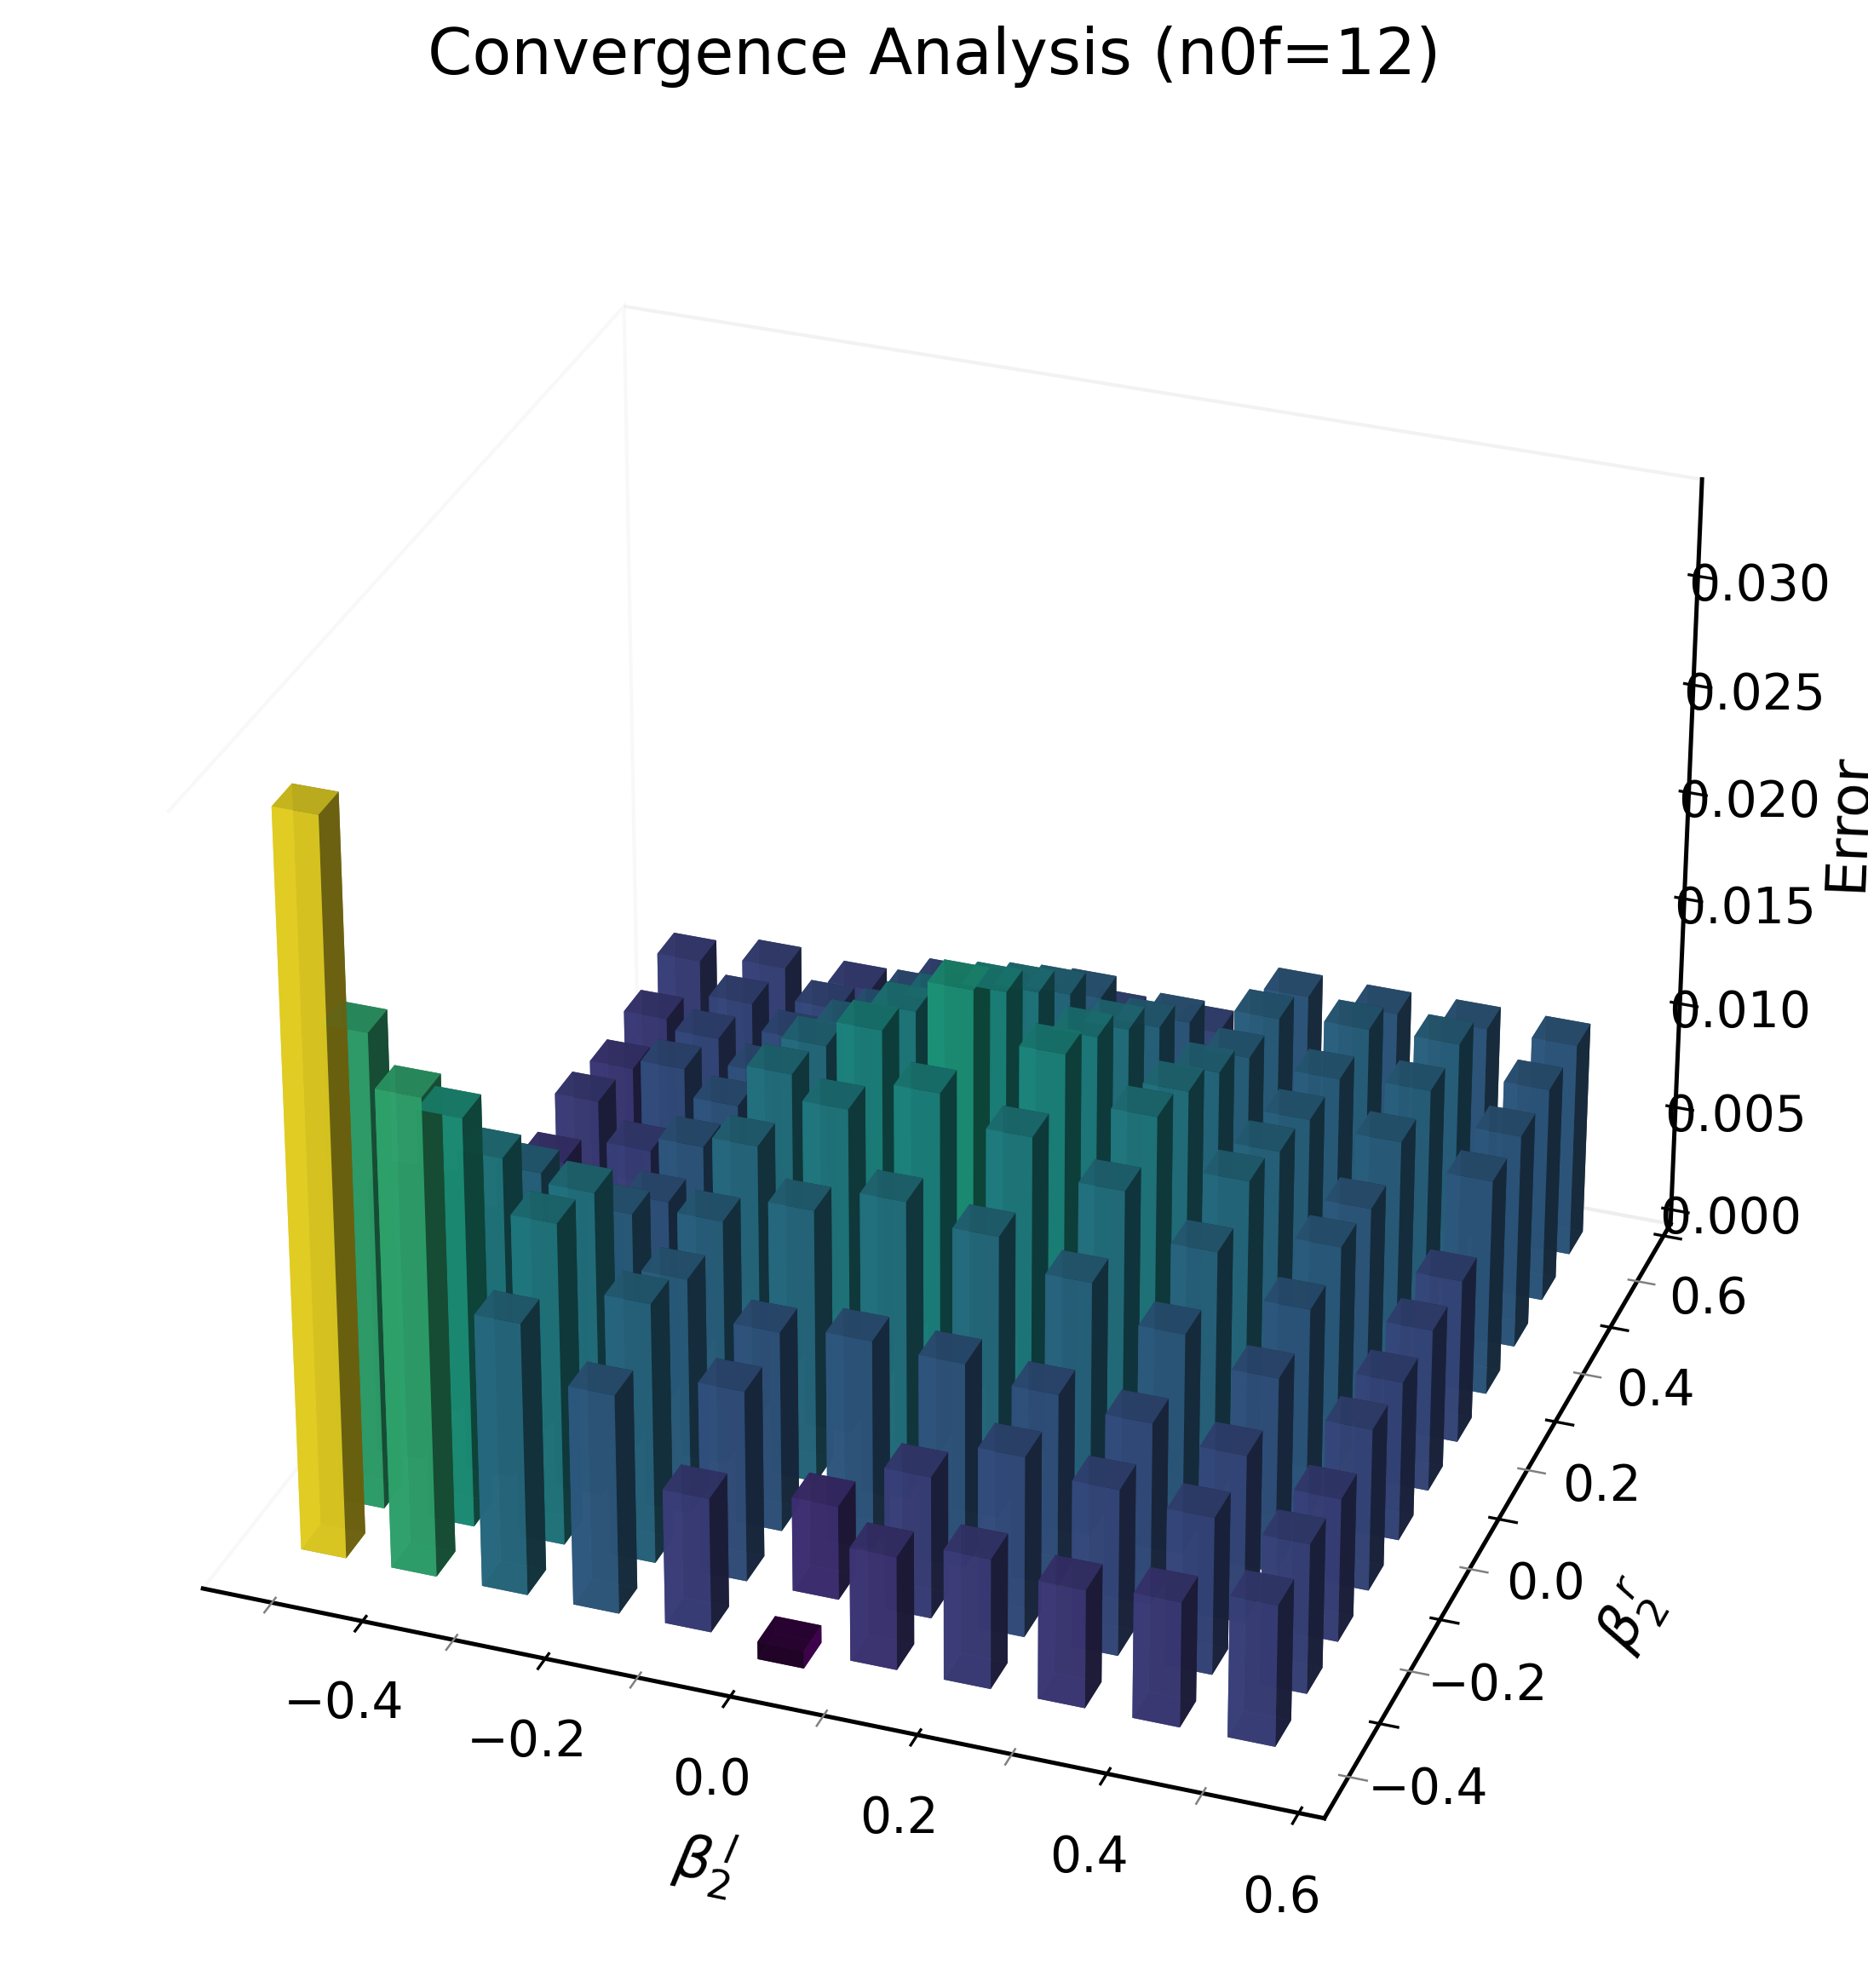

    n0f  beta2_l  beta2_r  nbeta          E0      r2_1B      r2_2B    r2_1&2B  \
0  14.0     -0.5     -0.5   0.12  260.997939  260.99072 -137.28845  123.70227   

      error      r^2e      r^21      err       r^2  
0  0.007219  3.612464  3.612414  0.00005  3.564642  


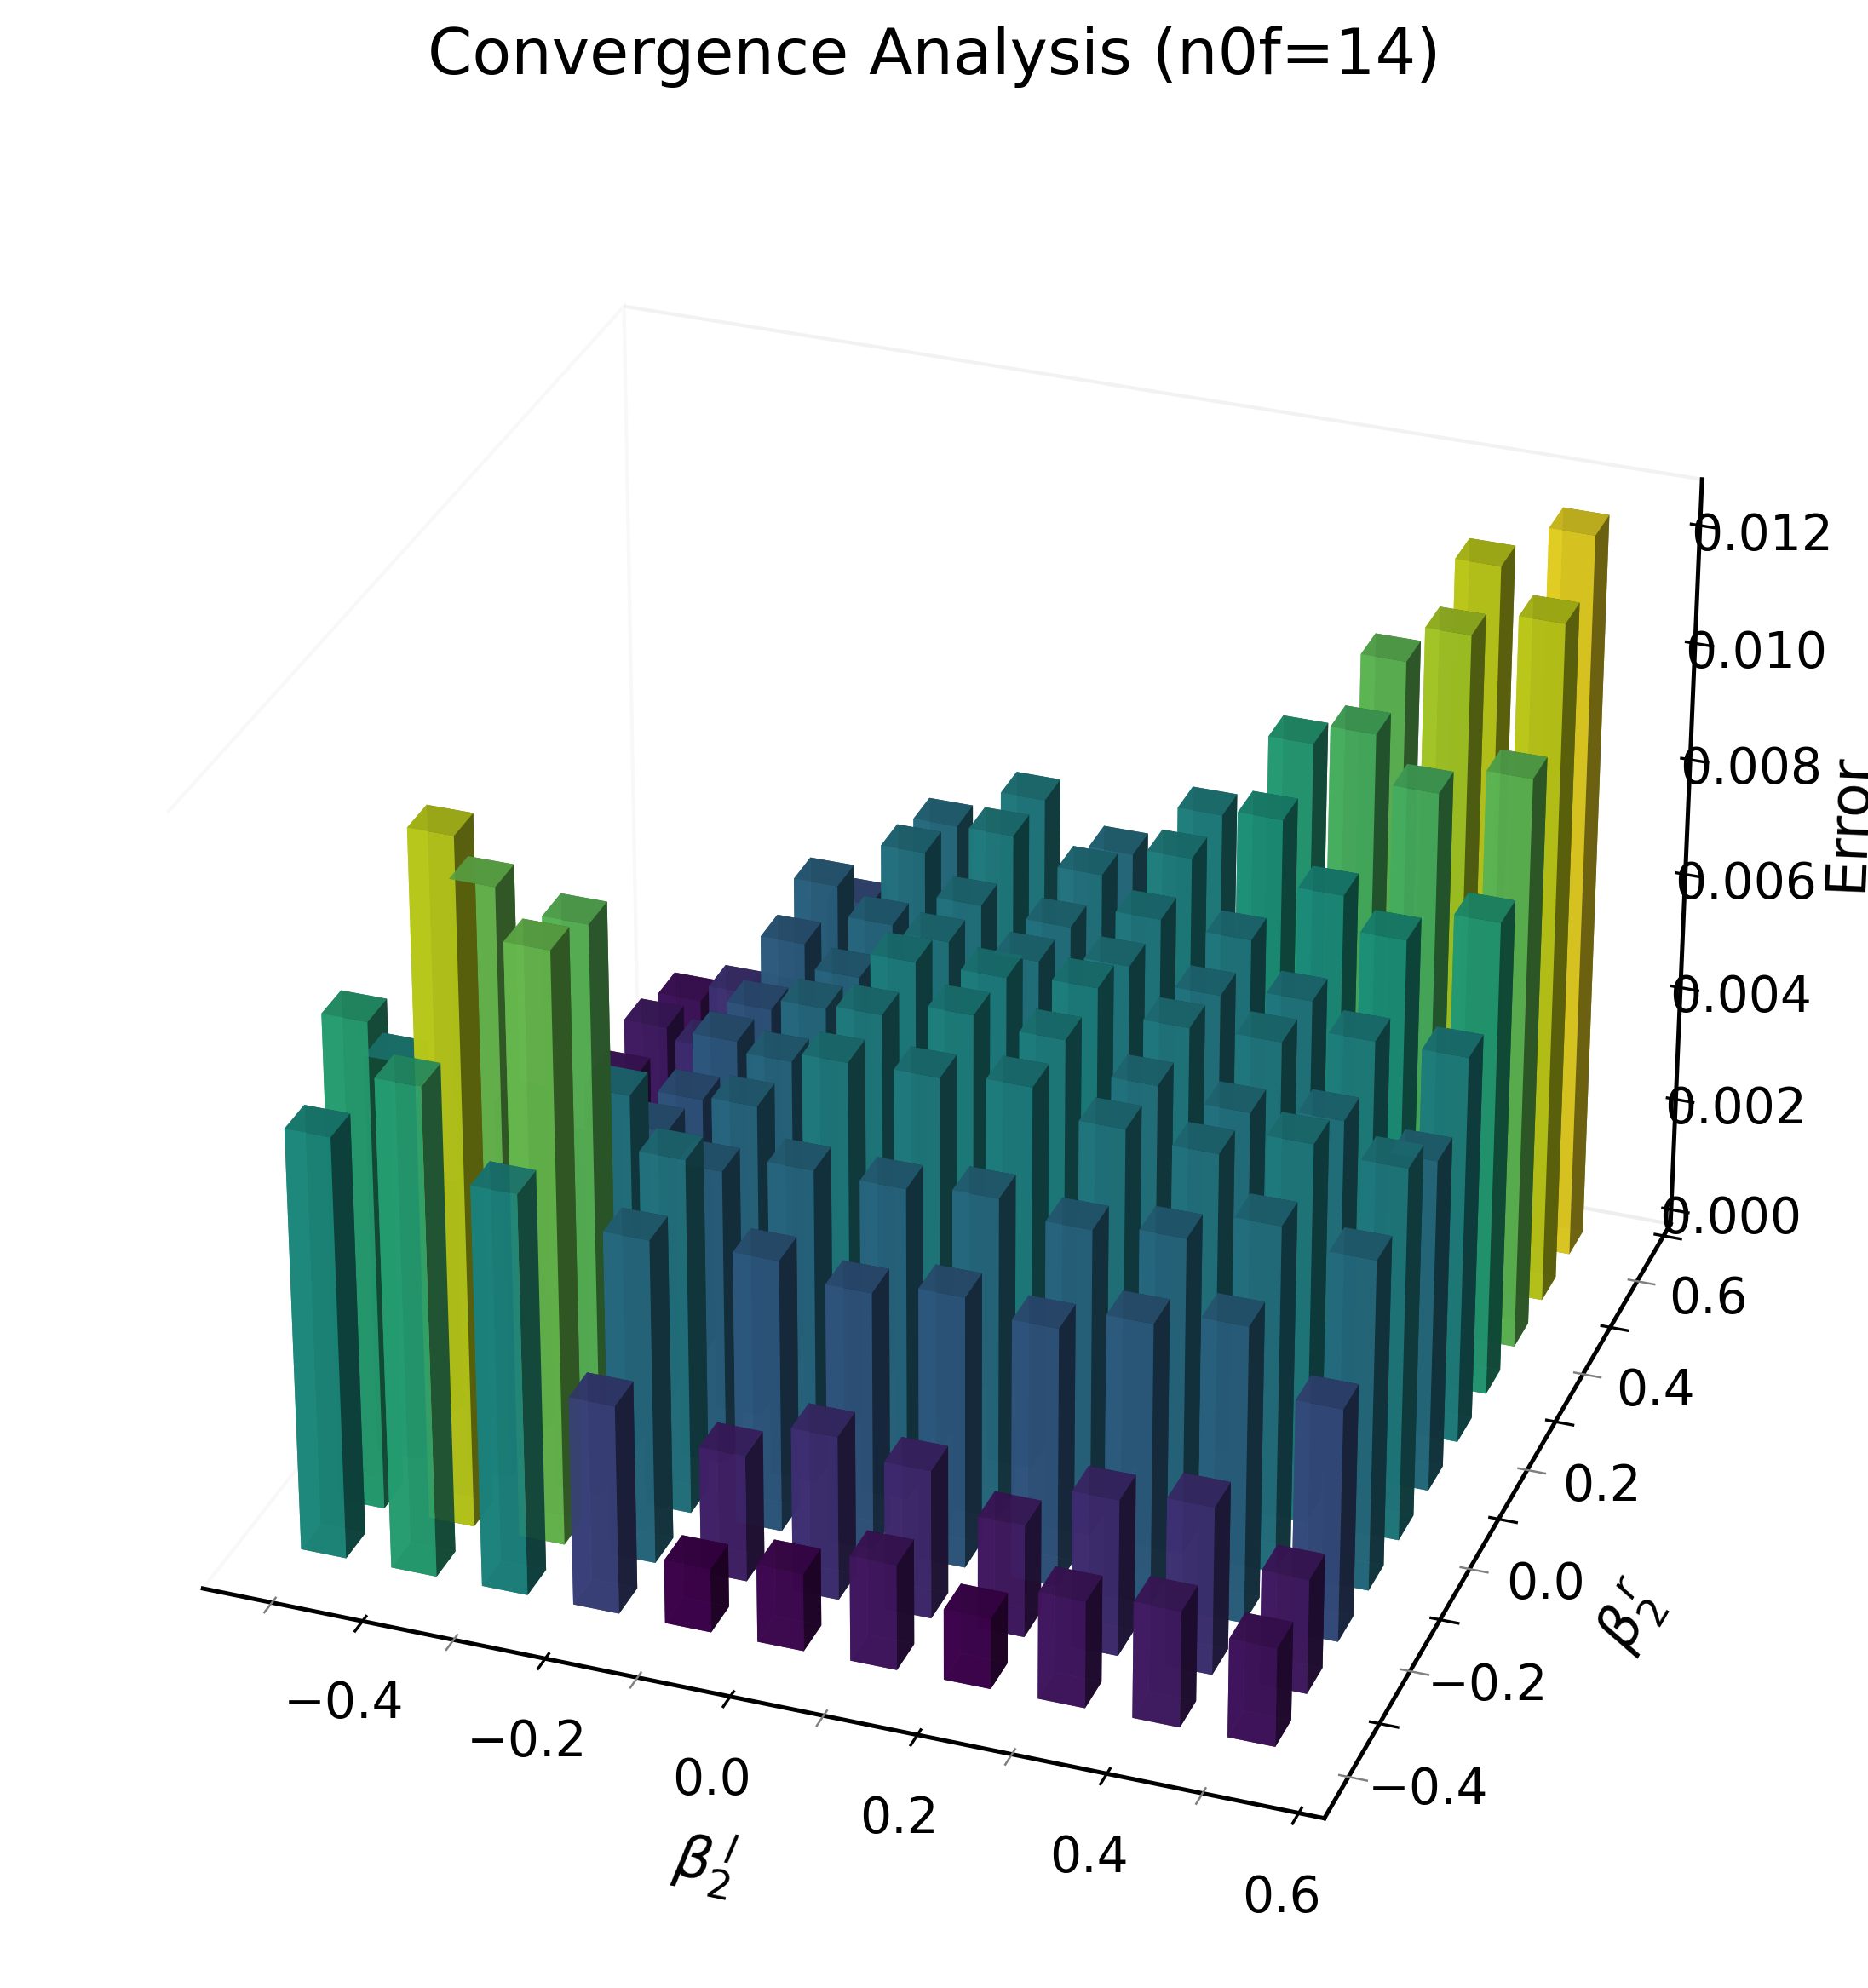

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl

# ---------- 全局字体设置（顶刊标配） ----------
# plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 1.2          # 坐标轴线宽
plt.rcParams['xtick.direction'] = 'in'        # 刻度向内
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# 辅刻度线
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['xtick.minor.size'] = 1
plt.rcParams['ytick.minor.size'] = 1
# plt.rcParams['xtick.minor.ndivs'] = 1
a = 4
for i in [1,5,0,3,2,4]:
    df_last = df_list[i]
    print(df_last.head(1))
    # 提取数据
    x = df_last['beta2_l'].values
    y = df_last['beta2_r'].values
    z = df_last['error'].values

    dx = dy = 0.05
    dz = z

    # 颜色映射（保持 viridis，也可换成 turbo）
    norm = plt.Normalize(z.min(), z.max())
    colors = plt.cm.viridis(norm(z))

    fig = plt.figure(figsize=(12, 8), dpi=300)   # 高分辨率
    ax = fig.add_subplot(111, projection='3d')

    # ---------- 顶刊美化：去除网格、背景面板 ----------
    ax.grid(False)                              # 关闭网格线
    ax.xaxis.pane.fill = False                  # 隐藏 x 轴背景面板
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.tick_params(which='minor', colors='gray', width=1)
    ax.tick_params(which='major', colors='black')
    from matplotlib.ticker import AutoMinorLocator

    # 每个主刻度之间分成 N 等份（如 2 表示主刻度间加 1 个辅刻度）
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    # ax.xaxis.pane.set_edgecolor('none')         # 去掉面板边框
    # ax.yaxis.pane.set_edgecolor('none')
    # ax.zaxis.pane.set_edgecolor('none')

    # ---------- 绘制柱子 ----------
    ax.bar3d(x, y, np.zeros_like(z), dx, dy, dz,
             color=colors, shade=True, alpha=0.9)

    # ---------- 坐标轴标签 ----------
    ax.set_xlabel(r'$\beta_{2}^{\,l}$', fontsize=16, labelpad=10)
    ax.set_ylabel(r'$\beta_{2}^{\,r}$', fontsize=16, labelpad=10)
    ax.set_zlabel('Error', fontsize=16, labelpad=10)
    ax.set_title(f'Convergence Analysis (n0f={a})', fontsize=18, pad=20)
    a += 2
    # ---------- 调整视角 ----------
    ax.view_init(elev=30, azim=-70)             # 俯角30°，方位角-60°

    # ---------- 保存为 PDF（矢量图，顶刊要求） ----------
    plt.tight_layout()
    plt.savefig(f'convergence_{i}.pdf', bbox_inches='tight')
    plt.show()

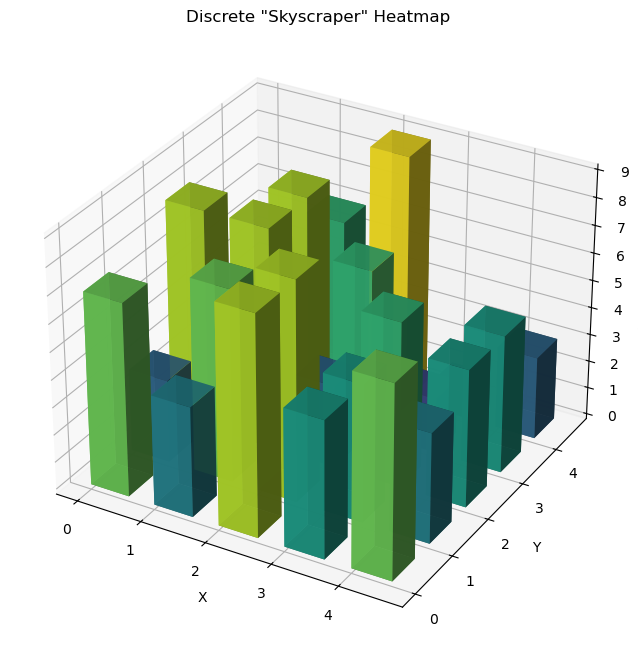

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 生成分立数据：假设在 x=[0,4], y=[0,4] 网格上有 5x5=25 个点
np.random.seed(42)
x = np.arange(5)   # 0,1,2,3,4
y = np.arange(5)
x, y = np.meshgrid(x, y)  # 产生网格坐标
z = np.random.randint(1, 10, size=x.shape)  # 高度值（整数，模拟分立）

# 展平成一维数组（bar3d 需要）
x_flat = x.ravel()
y_flat = y.ravel()
z_flat = z.ravel()

# 设置柱子尺寸（dx, dy 为底面积，dz 为高度）
dx = dy = 0.6   # 柱子宽度，留出间隙
dz = z_flat     # 每根柱子高度

# 颜色映射：根据高度着色
colors = plt.cm.viridis(z_flat / z_flat.max())  # 归一化后取色

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 绘制三维柱状图
ax.bar3d(x_flat, y_flat, np.zeros_like(z_flat), dx, dy, dz,
         color=colors, shade=True, alpha=0.9)

# 装饰
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Height (Value)')
ax.set_title('Convergence analysis')
plt.show()